In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
data_path = "/home/tahas44/Desktop/NYC-Taxi/datas/yellow_tripdata_2015-01.parquet"
df = pd.read_parquet(data_path)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None


### Step1: Data Understanding

In [3]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,1,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,N,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,None,None
12741031,1,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,N,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,None,None
12741032,1,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,N,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,None,None
12741033,1,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,N,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,None,None


In [4]:
# data_path = "/home/tahas44/Desktop/NYC-Taxi/datas/yellow_tripdata_2015-02.parquet"
# df_1 = pd.read_parquet(data_path)
# df_1.head()

In [5]:
# df_1.columns

In [6]:
df[df["airport_fee"].notna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [7]:
df[df["congestion_surcharge"].notna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [8]:
df.drop(columns=["VendorID", "store_and_fwd_flag", "congestion_surcharge", "airport_fee"], inplace=True)

In [9]:
df.isna().sum() # ne kadar NA değerim var?

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
dtype: int64

Duplicate veri var mı?

In [10]:
df[df.duplicated()]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
495485,2015-01-02 12:45:27,2015-01-02 12:57:28,1,2.30,1,186,142,2,10.5,0.0,0.5,0.0,0.0,0.0,11.3
539505,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
542584,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
543221,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
545806,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5572083,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8
5573035,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8
5578913,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8
5579596,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8


In [11]:
# 229 tane duplicate veri ile karşılaştıktan sonra bunlardan kurtulmam gerek
df.drop_duplicates(inplace=True)

### Step2: Data Cleaning for Logic

Data Cleaning için 3 farklı metot belirledim ve bu metotlar right skewed veri dağılımı için uygun yöntemler. Bu yöntemler sonucunda elimdeki veriden çöpleri çıkaracağım.

### 2.1 fare_amount

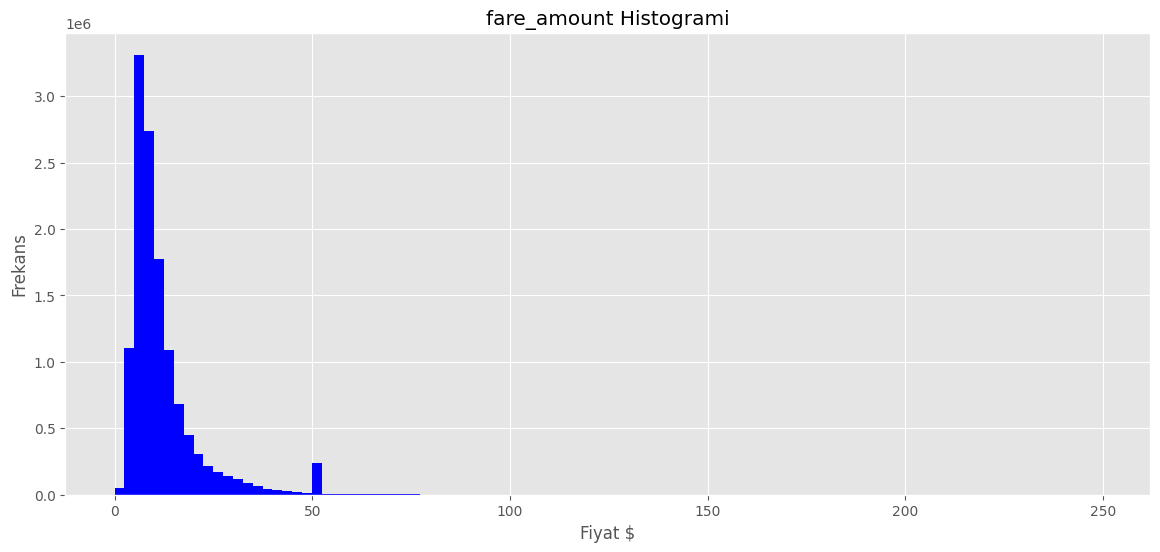

In [12]:
# Histogram ile oynama
plt.figure(figsize=(14,6))

df[(df["fare_amount"] < 250) & (df["fare_amount"] > 0)]["fare_amount"].plot(
    kind="hist", 
    bins=100, 
    color="blue"
)
plt.title("fare_amount Histogrami")
plt.xlabel("Fiyat $")
plt.ylabel("Frekans")
plt.show()

Grafikten elde edilen sonuç: fare_amount right skewed bir dağılım sergilemekte. Klasik Z score kullanılamaz!

IQR for fare_amount

In [13]:
indexes = df[df["fare_amount"] <= 0].index
df.drop(index=indexes, inplace=True)

In [14]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 6.5, Q3: 13.5, IQR: 7.0
Lower Bound: -4.0, Upper Bound: 24.0


In [15]:
# Lets see the outliers
df[(df["fare_amount"] < lower_bound) | (df["fare_amount"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
25,2015-01-01 00:44:34,2015-01-01 01:16:15,1,8.80,1,142,65,1,30.5,0.5,0.5,7.95,0.00,0.0,39.75
43,2015-01-01 00:54:32,2015-01-01 01:30:34,1,7.64,1,236,256,1,28.0,0.5,0.5,5.70,0.00,0.3,35.00
116,2015-01-01 00:54:26,2015-01-01 01:44:20,2,8.10,1,166,13,2,35.0,0.5,0.5,0.00,0.00,0.0,36.30
132,2015-01-01 00:22:45,2015-01-01 00:48:57,1,6.80,1,79,166,1,24.5,0.5,0.5,5.15,0.00,0.0,30.95
158,2015-01-01 00:24:12,2015-01-01 00:58:55,1,14.00,1,50,227,2,42.0,0.5,0.5,0.00,0.00,0.0,43.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741009,2015-01-31 23:19:19,2015-02-01 00:15:08,3,13.00,1,163,220,1,49.5,0.5,0.5,15.00,4.88,0.3,70.68
12741015,2015-01-31 23:27:10,2015-02-01 00:07:33,1,12.72,1,114,55,1,40.5,0.5,0.5,5.00,5.33,0.3,52.13
12741025,2015-01-31 23:30:26,2015-02-01 00:30:05,1,13.75,1,148,89,2,46.5,0.5,0.5,0.00,5.33,0.3,53.13
12741028,2015-01-31 23:36:46,2015-02-01 00:13:32,1,8.10,1,239,129,2,30.0,0.5,0.5,0.00,0.00,0.3,31.30


İnceleme: IQR methodu 1M den fazla outliers olduğunu iddia ediyor!

Normalde gelişmiş Z skoru için eşik değer 3.5 alınır ama eğerr ben bu değeri alırsam verilerin çoğu solda biriktiğinden sağ tarafta büyük bir veri kaybı yaşarım. Bunun için bu sütunu normalize edilmiş kopyasını oluşturacağım.

In [16]:
# Median Absolute Deviation for fare_amount
df["fare_amount_normalize"] = np.log1p(df["fare_amount"])
general_median = df["fare_amount_normalize"].median()
sapmalar = (df["fare_amount_normalize"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_fare_amount_normalize"] = (0.6745 * (df["fare_amount_normalize"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,1.902108,0.757334
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,2.653242,0.663119
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,2.219203,0.157681
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,2.197225,0.199245
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,1.945910,0.674500
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,2.772589,0.888813
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,3.511545,2.286238


In [17]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'fare_amount_normalize', 'advanced_zscore_for_fare_amount_normalize'],
      dtype='object')

In [18]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,1.902108,0.757334
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,2.653242,0.663119
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,2.219203,0.157681
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,2.197225,0.199245
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,1.945910,0.674500
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,2.772589,0.888813
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,3.511545,2.286238


In [19]:
df[df["advanced_zscore_for_fare_amount_normalize"] > 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize
612,2015-01-01 00:01:44,2015-01-01 00:20:46,2,6.90,5,232,265,1,65.00,0.0,0.0,13.05,0.00,0.0,78.35,4.189655,3.568595
714,2015-01-01 00:17:51,2015-01-01 00:58:34,1,25.80,1,43,29,1,68.70,0.5,0.5,14.00,0.00,0.0,84.00,4.244200,3.671745
1758,2015-01-01 00:40:25,2015-01-01 00:40:42,1,10.10,5,41,41,1,77.00,0.0,0.0,3.00,0.00,0.0,80.30,4.356709,3.884507
1943,2015-01-01 00:36:07,2015-01-01 00:51:17,1,4.60,5,246,265,1,70.00,0.0,0.0,21.05,0.00,0.0,91.35,4.262680,3.706691
1966,2015-01-01 00:15:50,2015-01-01 00:29:01,2,10.40,5,262,265,1,65.00,0.0,0.0,0.00,9.75,0.0,75.05,4.189655,3.568595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12738913,2015-01-31 23:51:01,2015-01-31 23:51:04,1,0.00,5,264,241,1,73.55,0.0,0.0,18.46,0.00,0.3,92.31,4.311470,3.798957
12739292,2015-01-31 23:55:19,2015-02-01 00:51:27,1,29.10,5,100,265,1,125.00,0.0,0.0,31.32,0.00,0.3,156.62,4.836282,4.791417
12739484,2015-01-31 23:02:58,2015-01-31 23:39:41,1,29.00,1,132,156,2,75.50,0.5,0.5,0.00,10.66,0.3,87.46,4.337291,3.847786
12739695,2015-01-31 23:24:34,2015-02-01 00:00:46,2,24.71,1,132,228,2,65.00,0.5,0.5,0.00,0.00,0.3,66.30,4.189655,3.568595


In [20]:
df[df["advanced_zscore_for_fare_amount_normalize"] > 3.5]["fare_amount"].min()

np.float64(0.01)

İzlenim: Gelişmiş Z skoru IQR'ye göre daha naif ve 41K satırın outliers olduğunu iddia ediyor. Bu aralıkta 32 dolar gibi makul değerler de olduğundan son bir quantile çalışması yapacağım.

In [21]:
df["fare_amount"].quantile(0.999)

np.float64(76.0)

In [22]:
percentage = 100 * len(df[df["fare_amount"] > 100]) / len(df)
print(f"100 den fazla değer içerenlerin yüzdesi {percentage}")

100 den fazla değer içerenlerin yüzdesi 0.04360769534076159


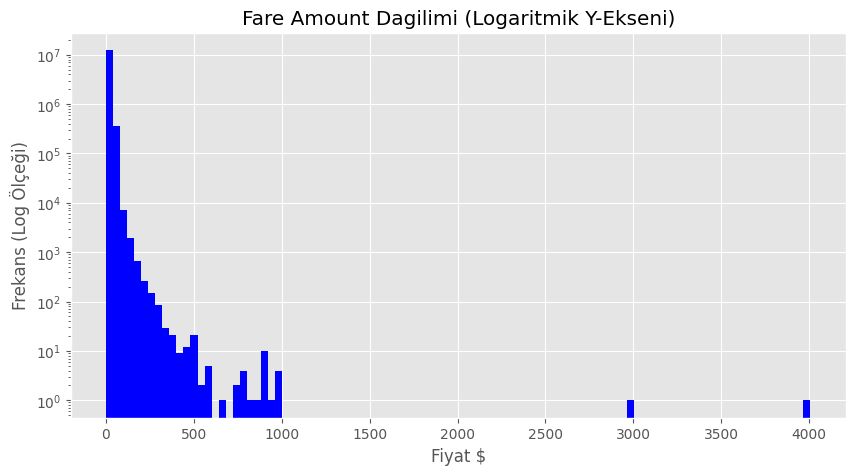

In [23]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [24]:
df[df["fare_amount"] > 100]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize
2592,2015-01-01 00:20:57,2015-01-01 00:24:59,3,2.80,5,223,74,3,120.0,0.0,0.0,0.00,5.33,0.0,125.63,4.795791,4.714845
10676,2015-01-01 00:36:39,2015-01-01 00:37:00,1,1.50,5,162,162,1,209.0,0.0,0.0,41.85,0.00,0.0,251.15,5.347108,5.757428
13153,2015-01-01 00:18:04,2015-01-01 00:55:56,3,18.75,5,48,265,2,120.0,0.0,0.0,0.00,0.00,0.3,120.30,4.795791,4.714845
14257,2015-01-01 00:51:33,2015-01-01 00:52:23,1,0.00,5,264,37,1,250.0,0.0,0.5,50.00,0.00,0.3,300.80,5.525453,6.094693
15043,2015-01-01 00:16:00,2015-01-01 00:16:05,1,0.00,5,48,48,1,120.0,0.0,0.0,24.00,0.00,0.3,144.30,4.795791,4.714845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12695967,2015-01-31 22:25:06,2015-01-31 22:58:32,1,25.70,4,132,132,1,120.5,0.5,0.5,24.36,0.00,0.3,146.16,4.799914,4.722643
12709257,2015-01-31 22:49:14,2015-01-31 22:49:34,1,17.70,5,265,265,1,102.0,0.0,0.0,20.45,0.00,0.3,122.75,4.634729,4.410265
12728578,2015-01-31 23:33:04,2015-02-01 01:09:52,1,34.90,1,230,187,2,104.0,0.5,0.5,0.00,10.66,0.3,115.96,4.653960,4.446633
12739292,2015-01-31 23:55:19,2015-02-01 00:51:27,1,29.10,5,100,265,1,125.0,0.0,0.0,31.32,0.00,0.3,156.62,4.836282,4.791417


In [25]:
indexes = df[df["trip_distance"] <= 0].index
df.drop(index=indexes, inplace=True)

In [26]:
df["fare_per_distance"] = df["fare_amount"] / df["trip_distance"]
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,1.902108,0.757334,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,2.653242,0.663119,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,2.219203,0.157681,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,2.197225,0.199245,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,1.945910,0.674500,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,2.772589,0.888813,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,3.511545,2.286238,4.710145


In [27]:
df["fare_per_distance"].max()

np.float64(27500.0)

In [28]:
df["fare_per_distance"].min()   #!

np.float64(2.0272790671272644e-07)

In [29]:
df["fare_per_distance"].quantile(0.999)

np.float64(62.5)

In [30]:
df[df["fare_per_distance"] > 70]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize,fare_per_distance
2228,2015-01-01 00:07:48,2015-01-01 00:09:21,2,0.04,1,79,79,2,3.0,0.5,0.5,0.00,0.0,0.3,4.30,1.386294,1.732777,75.000000
3288,2015-01-01 00:13:09,2015-01-01 00:13:19,1,0.02,1,151,264,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.252763,1.985295,125.000000
3304,2015-01-01 00:26:48,2015-01-01 00:27:21,2,0.30,5,262,262,1,76.0,0.0,0.5,11.52,0.0,0.3,88.32,4.343805,3.860106,253.333333
4001,2015-01-01 00:38:48,2015-01-01 00:39:13,1,0.03,1,142,142,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.252763,1.985295,83.333333
4436,2015-01-01 00:19:28,2015-01-01 00:20:25,1,0.03,1,79,79,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.252763,1.985295,83.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12737568,2015-01-31 23:30:43,2015-01-31 23:31:49,2,0.01,1,249,249,2,3.0,0.5,0.5,0.00,0.0,0.3,4.30,1.386294,1.732777,300.000000
12739797,2015-01-31 23:07:36,2015-01-31 23:07:48,2,0.01,1,48,264,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.252763,1.985295,250.000000
12740641,2015-01-31 23:11:31,2015-01-31 23:12:07,5,0.03,1,229,229,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.252763,1.985295,83.333333
12740966,2015-01-31 23:10:01,2015-01-31 23:10:32,1,0.05,2,264,264,2,52.0,0.0,0.5,0.00,0.0,0.3,52.80,3.970292,3.153763,1040.000000


- değeri 100 den fazla olduğu halde normal olan fare_amount var mı?

In [31]:
df[(df["fare_amount"] > 100) & (df["fare_per_distance"] < 70)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize,fare_per_distance
2592,2015-01-01 00:20:57,2015-01-01 00:24:59,3,2.80,5,223,74,3,120.00,0.0,0.0,0.00,5.33,0.0,125.63,4.795791,4.714845,42.857143
13153,2015-01-01 00:18:04,2015-01-01 00:55:56,3,18.75,5,48,265,2,120.00,0.0,0.0,0.00,0.00,0.3,120.30,4.795791,4.714845,6.400000
15515,2015-01-01 00:50:08,2015-01-01 01:25:54,2,27.96,5,68,265,1,137.00,0.0,0.5,29.60,11.00,0.3,178.40,4.927254,4.963452,4.899857
16978,2015-01-01 00:26:43,2015-01-01 00:34:29,3,2.67,5,68,265,2,120.00,0.0,0.5,0.00,11.75,0.3,132.55,4.795791,4.714845,44.943820
17969,2015-01-01 00:16:53,2015-01-01 00:59:30,2,23.07,5,138,265,1,133.33,0.0,0.0,26.67,0.00,0.3,160.30,4.900299,4.912479,5.779367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12695967,2015-01-31 22:25:06,2015-01-31 22:58:32,1,25.70,4,132,132,1,120.50,0.5,0.5,24.36,0.00,0.3,146.16,4.799914,4.722643,4.688716
12709257,2015-01-31 22:49:14,2015-01-31 22:49:34,1,17.70,5,265,265,1,102.00,0.0,0.0,20.45,0.00,0.3,122.75,4.634729,4.410265,5.762712
12728578,2015-01-31 23:33:04,2015-02-01 01:09:52,1,34.90,1,230,187,2,104.00,0.5,0.5,0.00,10.66,0.3,115.96,4.653960,4.446633,2.979943
12739292,2015-01-31 23:55:19,2015-02-01 00:51:27,1,29.10,5,100,265,1,125.00,0.0,0.0,31.32,0.00,0.3,156.62,4.836282,4.791417,4.295533


In [32]:
df[(df["fare_amount"] < 100) & (df["fare_per_distance"] < 70)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,1.902108,0.757334,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,2.653242,0.663119,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,2.219203,0.157681,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,2.197225,0.199245,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,1.945910,0.674500,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,2.772589,0.888813,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,3.511545,2.286238,4.710145


In [33]:
indexes = df[(df["fare_amount"] > 100) & (df["fare_per_distance"] > 70)].index
df.drop(index=indexes, inplace=True)

In [34]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,fare_amount_normalize,advanced_zscore_for_fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,1.902108,0.757334,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,2.653242,0.663119,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,2.219203,0.157681,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,1.945910,0.674500,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,2.197225,0.199245,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,1.945910,0.674500,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,2.772589,0.888813,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,3.511545,2.286238,4.710145


In [35]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'fare_amount_normalize', 'advanced_zscore_for_fare_amount_normalize',
       'fare_per_distance'],
      dtype='object')

In [36]:
df.drop(columns=["advanced_zscore_for_fare_amount_normalize", "fare_amount_normalize", "fare_per_distance"], inplace=True)

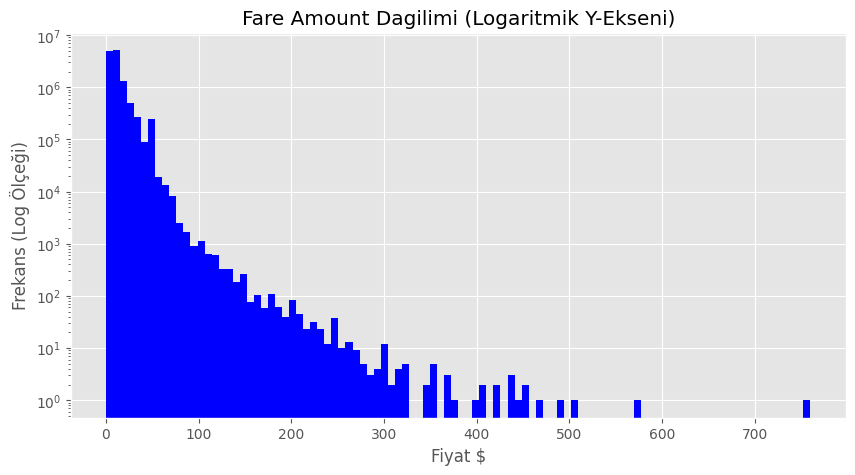

In [37]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

Bu temizlenmiş yeni hali inceleyelim

In [38]:
df["fare_amount"].max()

np.float64(760.01)

In [39]:
df[df["fare_amount"] > 400]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1202886,2015-01-04 05:40:11,2015-01-04 05:55:00,3,8.70,5,138,216,2,405.00,0.0,0.0,0.0,0.00,0.0,405.30
1258952,2015-01-04 11:09:41,2015-01-04 12:16:19,1,52.11,5,161,265,1,440.00,0.0,0.0,59.0,0.00,0.3,499.30
1260451,2015-01-04 11:11:03,2015-01-04 12:16:32,1,51.42,5,161,265,1,448.00,0.0,0.0,50.0,0.00,0.0,498.00
1943898,2015-01-06 10:26:25,2015-01-06 11:47:49,1,69.09,5,132,265,1,420.00,0.0,0.0,33.0,0.00,0.3,453.30
3626812,2015-01-10 05:17:04,2015-01-10 07:58:48,1,99.89,4,162,265,2,503.50,0.5,0.5,0.0,0.00,0.3,504.80
5192918,2015-01-13 19:42:12,2015-01-13 21:59:41,1,99.90,5,132,265,1,570.08,0.0,0.0,20.0,0.00,0.3,590.38
5495781,2015-01-14 12:01:10,2015-01-14 14:28:22,2,99.90,5,215,265,1,450.00,0.0,0.0,0.0,0.00,0.3,450.30
7744382,2015-01-19 14:00:19,2015-01-19 15:17:05,1,74.40,4,132,265,2,410.00,0.0,0.5,0.0,6.83,0.3,417.63
8470138,2015-01-21 10:49:17,2015-01-21 13:48:26,3,99.90,5,132,265,1,425.00,0.0,0.0,0.0,0.00,0.3,425.30
9367943,2015-01-23 10:34:58,2015-01-23 11:42:13,1,15.09,5,48,242,2,467.54,0.0,0.5,0.0,0.00,0.3,468.34


In [40]:
df["fare_amount"].min() #!

np.float64(0.01)

In [41]:
df[df["fare_amount"] < 1]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12211,2015-01-01 00:17:37,2015-01-01 00:24:49,1,1.66,5,83,83,2,0.01,0.0,0.5,0.0,0.00,0.3,0.81
16829,2015-01-01 00:41:30,2015-01-01 00:42:27,3,7.00,5,17,17,2,0.03,0.0,0.0,0.0,0.00,0.3,0.33
25073,2015-01-01 00:04:23,2015-01-01 00:06:09,1,0.40,5,265,265,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
26510,2015-01-01 00:06:40,2015-01-01 00:27:12,1,1.60,5,161,143,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
28207,2015-01-01 00:01:36,2015-01-01 00:29:26,4,18.50,5,132,113,3,0.01,0.0,0.0,0.0,5.33,0.0,5.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12393944,2015-01-31 11:31:08,2015-01-31 11:55:08,3,4.10,5,262,263,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12545820,2015-01-31 17:51:30,2015-01-31 17:53:14,1,0.30,5,236,236,4,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12696381,2015-01-31 22:33:49,2015-01-31 22:44:36,1,2.50,5,125,265,1,0.60,0.0,0.0,65.0,0.00,0.3,65.90
12729769,2015-01-31 23:51:09,2015-02-01 00:45:58,1,32.10,5,246,143,3,0.01,0.0,0.0,0.0,2.44,0.3,2.75


In [42]:
indexes = df[df["passenger_count"] <= 0].index
df.drop(index=indexes, inplace=True)

In [43]:
df[df["fare_amount"] < 0.1]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12211,2015-01-01 00:17:37,2015-01-01 00:24:49,1,1.66,5,83,83,2,0.01,0.0,0.5,0.0,0.00,0.3,0.81
16829,2015-01-01 00:41:30,2015-01-01 00:42:27,3,7.00,5,17,17,2,0.03,0.0,0.0,0.0,0.00,0.3,0.33
25073,2015-01-01 00:04:23,2015-01-01 00:06:09,1,0.40,5,265,265,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
26510,2015-01-01 00:06:40,2015-01-01 00:27:12,1,1.60,5,161,143,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
28207,2015-01-01 00:01:36,2015-01-01 00:29:26,4,18.50,5,132,113,3,0.01,0.0,0.0,0.0,5.33,0.0,5.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12315612,2015-01-31 05:03:51,2015-01-31 05:04:34,1,0.76,5,265,265,2,0.01,0.0,0.0,0.0,28.00,0.3,28.31
12316457,2015-01-31 05:06:14,2015-01-31 05:15:09,1,0.70,5,201,201,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12393944,2015-01-31 11:31:08,2015-01-31 11:55:08,3,4.10,5,262,263,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12545820,2015-01-31 17:51:30,2015-01-31 17:53:14,1,0.30,5,236,236,4,0.01,0.0,0.0,0.0,0.00,0.3,0.31


In [44]:
df[df["fare_amount"] < 1]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12211,2015-01-01 00:17:37,2015-01-01 00:24:49,1,1.66,5,83,83,2,0.01,0.0,0.5,0.0,0.00,0.3,0.81
16829,2015-01-01 00:41:30,2015-01-01 00:42:27,3,7.00,5,17,17,2,0.03,0.0,0.0,0.0,0.00,0.3,0.33
25073,2015-01-01 00:04:23,2015-01-01 00:06:09,1,0.40,5,265,265,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
26510,2015-01-01 00:06:40,2015-01-01 00:27:12,1,1.60,5,161,143,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
28207,2015-01-01 00:01:36,2015-01-01 00:29:26,4,18.50,5,132,113,3,0.01,0.0,0.0,0.0,5.33,0.0,5.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12316457,2015-01-31 05:06:14,2015-01-31 05:15:09,1,0.70,5,201,201,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12393944,2015-01-31 11:31:08,2015-01-31 11:55:08,3,4.10,5,262,263,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12545820,2015-01-31 17:51:30,2015-01-31 17:53:14,1,0.30,5,236,236,4,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12696381,2015-01-31 22:33:49,2015-01-31 22:44:36,1,2.50,5,125,265,1,0.60,0.0,0.0,65.0,0.00,0.3,65.90


In [45]:
indexes = df[df["fare_amount"] < 1].index
df.drop(index=indexes, inplace=True)

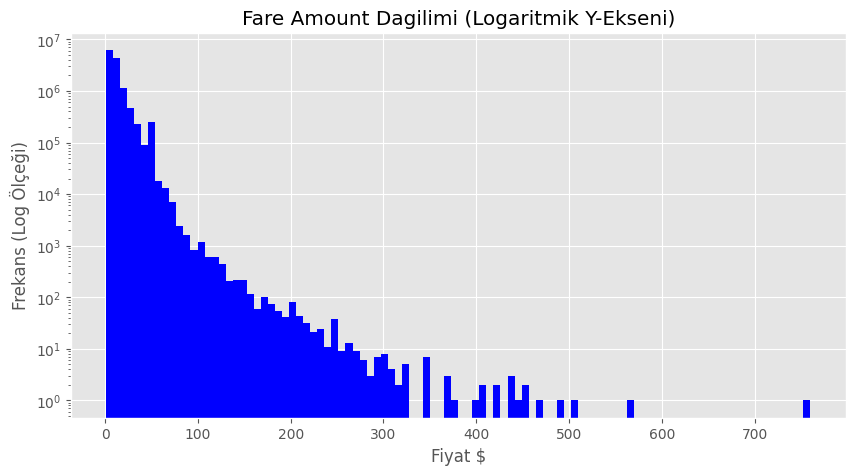

In [46]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

In [47]:
df[df["fare_amount"] > 700]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
11865623,2015-01-30 10:42:15,2015-01-30 11:08:51,1,16.7,5,263,265,3,760.01,0.0,0.0,0.0,0.0,0.3,760.31


In [48]:
df[df["fare_amount"] > 400]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1202886,2015-01-04 05:40:11,2015-01-04 05:55:00,3,8.70,5,138,216,2,405.00,0.0,0.0,0.0,0.00,0.0,405.30
1258952,2015-01-04 11:09:41,2015-01-04 12:16:19,1,52.11,5,161,265,1,440.00,0.0,0.0,59.0,0.00,0.3,499.30
1260451,2015-01-04 11:11:03,2015-01-04 12:16:32,1,51.42,5,161,265,1,448.00,0.0,0.0,50.0,0.00,0.0,498.00
1943898,2015-01-06 10:26:25,2015-01-06 11:47:49,1,69.09,5,132,265,1,420.00,0.0,0.0,33.0,0.00,0.3,453.30
3626812,2015-01-10 05:17:04,2015-01-10 07:58:48,1,99.89,4,162,265,2,503.50,0.5,0.5,0.0,0.00,0.3,504.80
5192918,2015-01-13 19:42:12,2015-01-13 21:59:41,1,99.90,5,132,265,1,570.08,0.0,0.0,20.0,0.00,0.3,590.38
5495781,2015-01-14 12:01:10,2015-01-14 14:28:22,2,99.90,5,215,265,1,450.00,0.0,0.0,0.0,0.00,0.3,450.30
7744382,2015-01-19 14:00:19,2015-01-19 15:17:05,1,74.40,4,132,265,2,410.00,0.0,0.5,0.0,6.83,0.3,417.63
8470138,2015-01-21 10:49:17,2015-01-21 13:48:26,3,99.90,5,132,265,1,425.00,0.0,0.0,0.0,0.00,0.3,425.30
9367943,2015-01-23 10:34:58,2015-01-23 11:42:13,1,15.09,5,48,242,2,467.54,0.0,0.5,0.0,0.00,0.3,468.34


In [49]:
indexes = df[(df["fare_amount"] > 400) & (df["trip_distance"] < 20)].index
df.drop(index=indexes, inplace=True)

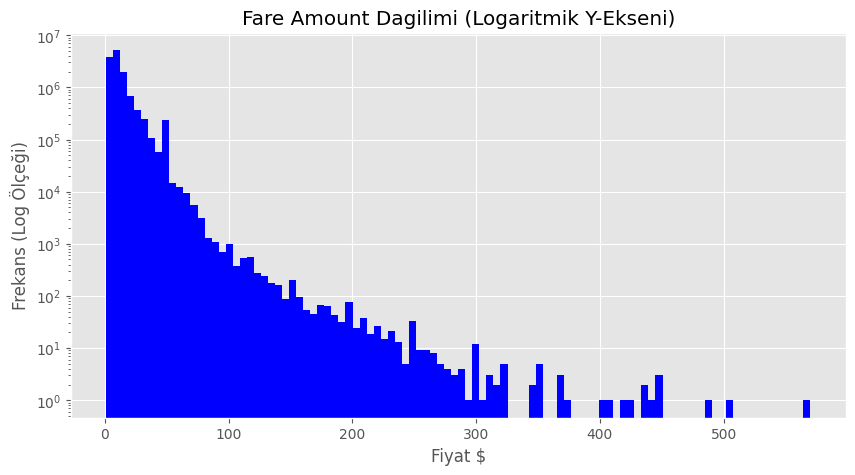

In [50]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

Sonuç: fare_amount son haline getirildi!

### 2.2 extra

In [51]:
indexes = df[df["extra"] < 0].index
df.drop(index=indexes, inplace=True)

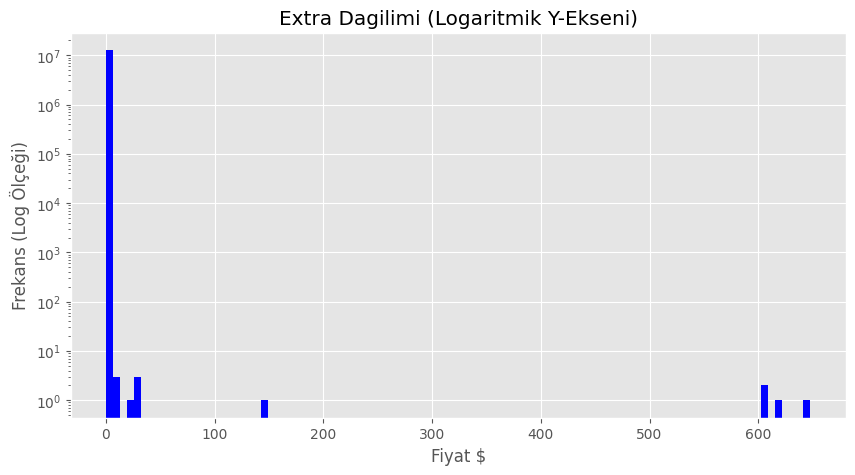

In [52]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['extra'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Extra Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [53]:
df[df["extra"] > 600]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
7220561,2015-01-18 02:39:09,2015-01-18 02:56:05,1,10.0,1,230,196,3,82.0,606.12,0.5,0.0,0.0,0.3,688.92
8457819,2015-01-21 10:36:50,2015-01-21 10:39:50,1,0.6,6,229,140,2,12.0,620.92,0.5,0.0,0.0,0.3,633.72
9492700,2015-01-23 16:53:30,2015-01-23 17:05:02,1,0.8,1,41,42,2,8.0,648.02,0.5,0.0,0.0,0.3,656.82
10533974,2015-01-25 21:23:56,2015-01-25 21:31:46,1,2.0,1,4,137,2,2.1,605.45,0.5,0.0,0.0,0.3,608.35


In [54]:
df["extra"].median()

np.float64(0.0)

"extra" right skewed bir dağılım sergilemekte. Klasik Z score kullanılamaz!

In [55]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["extra"].quantile(0.25)
Q3 = df["extra"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 0.0, Q3: 0.5, IQR: 0.5
Lower Bound: -0.75, Upper Bound: 1.25


In [56]:
# Lets see the outliers
df[(df["extra"] < lower_bound) | (df["extra"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2166,2015-01-01 00:18:27,2015-01-01 00:32:45,1,3.1,1,138,129,2,13.0,1.5,0.5,0.00,0.0,0.0,15.30
87753,2015-01-01 02:15:56,2015-01-01 02:25:17,1,1.3,1,237,142,1,7.7,4.5,0.5,3.90,0.0,0.0,16.90
144374,2015-01-01 06:49:53,2015-01-01 07:07:12,1,3.9,1,112,37,1,15.5,2.0,0.5,3.65,0.0,0.0,21.95
150542,2015-01-01 07:54:51,2015-01-01 07:57:23,1,9.9,1,170,170,4,3.5,1.5,0.5,0.00,0.0,0.0,5.80
257987,2015-01-01 16:03:14,2015-01-01 16:12:52,1,1.5,1,239,230,2,8.0,1.5,0.5,0.00,0.0,0.0,10.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11615710,2015-01-29 19:39:04,2015-01-29 19:51:36,2,1.5,1,162,140,1,9.5,1.5,0.5,2.95,0.0,0.3,14.75
11624284,2015-01-29 19:05:17,2015-01-29 19:09:00,1,1.2,1,143,239,1,5.5,1.5,0.5,1.56,0.0,0.3,9.36
12083294,2015-01-30 19:01:29,2015-01-30 19:10:22,1,0.9,1,125,231,1,7.0,1.5,0.5,1.85,0.0,0.3,11.15
12127463,2015-01-30 20:50:27,2015-01-30 20:51:10,1,0.7,1,132,132,3,2.5,2.0,0.5,0.00,0.0,0.3,5.30


In [57]:
df[(df["extra"] == 1.5) | (df["extra"] == 2.0)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2166,2015-01-01 00:18:27,2015-01-01 00:32:45,1,3.1,1,138,129,2,13.0,1.5,0.5,0.00,0.0,0.0,15.30
144374,2015-01-01 06:49:53,2015-01-01 07:07:12,1,3.9,1,112,37,1,15.5,2.0,0.5,3.65,0.0,0.0,21.95
150542,2015-01-01 07:54:51,2015-01-01 07:57:23,1,9.9,1,170,170,4,3.5,1.5,0.5,0.00,0.0,0.0,5.80
257987,2015-01-01 16:03:14,2015-01-01 16:12:52,1,1.5,1,239,230,2,8.0,1.5,0.5,0.00,0.0,0.0,10.30
587549,2015-01-02 17:27:03,2015-01-02 17:31:01,1,1.0,1,229,137,1,5.5,1.5,0.5,1.55,0.0,0.0,9.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11615710,2015-01-29 19:39:04,2015-01-29 19:51:36,2,1.5,1,162,140,1,9.5,1.5,0.5,2.95,0.0,0.3,14.75
11624284,2015-01-29 19:05:17,2015-01-29 19:09:00,1,1.2,1,143,239,1,5.5,1.5,0.5,1.56,0.0,0.3,9.36
12083294,2015-01-30 19:01:29,2015-01-30 19:10:22,1,0.9,1,125,231,1,7.0,1.5,0.5,1.85,0.0,0.3,11.15
12127463,2015-01-30 20:50:27,2015-01-30 20:51:10,1,0.7,1,132,132,3,2.5,2.0,0.5,0.00,0.0,0.3,5.30


In [58]:
df[df["extra"] > 2]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
87753,2015-01-01 02:15:56,2015-01-01 02:25:17,1,1.3,1,237,142,1,7.70,4.50,0.5,3.90,0.00,0.0,16.90
1497820,2015-01-05 06:41:54,2015-01-05 07:05:39,1,2.7,1,148,25,2,16.50,7.00,0.5,0.00,0.00,0.3,24.30
2151694,2015-01-06 20:27:42,2015-01-06 20:35:51,1,2.1,1,237,162,2,8.50,2.50,0.5,0.00,0.00,0.3,11.80
2235674,2015-01-07 05:53:27,2015-01-07 06:35:43,1,16.7,1,25,74,1,49.00,3.00,0.5,0.50,0.00,0.3,53.30
2439086,2015-01-07 15:59:11,2015-01-07 16:31:44,1,18.3,2,132,74,1,52.00,2.46,0.5,8.80,5.33,0.3,69.39
3315713,2015-01-09 15:55:32,2015-01-09 16:35:58,1,17.7,2,132,107,2,52.00,2.46,0.5,0.00,5.33,0.3,60.59
3358414,2015-01-09 17:15:46,2015-01-09 18:07:08,1,10.6,2,61,132,1,52.00,2.46,0.5,16.57,0.00,0.3,71.83
3398680,2015-01-09 19:25:14,2015-01-09 19:30:34,1,0.8,1,97,97,2,5.50,5.00,0.5,0.00,0.00,0.3,11.30
3408317,2015-01-09 19:14:49,2015-01-09 19:40:41,1,15.5,1,138,265,1,42.50,3.00,0.5,15.00,0.00,0.3,61.30
3558751,2015-01-10 00:51:19,2015-01-10 01:15:57,1,4.9,1,68,256,4,20.50,28.50,0.5,0.00,0.00,0.3,49.80


IQR methodu upper bound olarak 1.25 diyor lakin 2 ve 1.25 arasında ihtiyacımız olan satırlar elenebilir. Bu yüzden IQR methodu sonucu 2'ye yuvarlanabilir.

In [59]:
df[(df["extra"] > 1.25) & (df["extra"] < 2.0)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
2166,2015-01-01 00:18:27,2015-01-01 00:32:45,1,3.1,1,138,129,2,13.0,1.5,0.5,0.00,0.0,0.0,15.30
150542,2015-01-01 07:54:51,2015-01-01 07:57:23,1,9.9,1,170,170,4,3.5,1.5,0.5,0.00,0.0,0.0,5.80
257987,2015-01-01 16:03:14,2015-01-01 16:12:52,1,1.5,1,239,230,2,8.0,1.5,0.5,0.00,0.0,0.0,10.30
587549,2015-01-02 17:27:03,2015-01-02 17:31:01,1,1.0,1,229,137,1,5.5,1.5,0.5,1.55,0.0,0.0,9.35
589867,2015-01-02 17:08:26,2015-01-02 17:17:49,1,1.2,1,264,264,1,7.0,1.5,0.5,1.85,0.0,0.0,11.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11586105,2015-01-29 18:18:45,2015-01-29 18:27:46,1,1.0,1,237,162,2,7.0,1.5,0.5,0.00,0.0,0.3,9.30
11595732,2015-01-29 18:45:15,2015-01-29 18:53:31,2,1.2,1,264,264,1,7.0,1.5,0.5,1.85,0.0,0.3,11.15
11615710,2015-01-29 19:39:04,2015-01-29 19:51:36,2,1.5,1,162,140,1,9.5,1.5,0.5,2.95,0.0,0.3,14.75
11624284,2015-01-29 19:05:17,2015-01-29 19:09:00,1,1.2,1,143,239,1,5.5,1.5,0.5,1.56,0.0,0.3,9.36


İzlenim: üst sınırı 2.0 almak makul gibi gözüküyor

In [60]:
# Median Absolute Deviation for fare_amount
general_median = df["extra"].median()
sapmalar = (df["extra"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_extra"] = (0.6745 * (df["extra"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_extra
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,inf
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,inf
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,inf
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,inf
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,inf
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,inf
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,inf
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,inf


Verilerin çoğunluğu sıfırda toplandığından MAD kullanamıyorum!

In [61]:
df["extra"].value_counts()

extra
0.00      6646794
0.50      4199393
1.00      1808805
0.01          185
1.50          137
0.02           40
2.00           14
0.30           11
3.00            5
2.46            5
4.00            4
1.23            4
0.80            4
2.50            3
4.50            2
7.00            2
0.19            1
28.50           1
5.00            1
0.70            1
12.50           1
606.12          1
3.50            1
24.71           1
146.75          1
620.92          1
26.56           1
648.02          1
1.30            1
0.20            1
29.01           1
605.45          1
5.50            1
Name: count, dtype: int64

In [62]:
df["extra"].quantile(0.999)

np.float64(1.0)

In [63]:
df[(df["extra"] > 1.0) & (df["extra"] < 2.0)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_extra
2166,2015-01-01 00:18:27,2015-01-01 00:32:45,1,3.1,1,138,129,2,13.0,1.5,0.5,0.00,0.0,0.0,15.30,inf
150542,2015-01-01 07:54:51,2015-01-01 07:57:23,1,9.9,1,170,170,4,3.5,1.5,0.5,0.00,0.0,0.0,5.80,inf
257987,2015-01-01 16:03:14,2015-01-01 16:12:52,1,1.5,1,239,230,2,8.0,1.5,0.5,0.00,0.0,0.0,10.30,inf
587549,2015-01-02 17:27:03,2015-01-02 17:31:01,1,1.0,1,229,137,1,5.5,1.5,0.5,1.55,0.0,0.0,9.35,inf
589867,2015-01-02 17:08:26,2015-01-02 17:17:49,1,1.2,1,264,264,1,7.0,1.5,0.5,1.85,0.0,0.0,11.15,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11586105,2015-01-29 18:18:45,2015-01-29 18:27:46,1,1.0,1,237,162,2,7.0,1.5,0.5,0.00,0.0,0.3,9.30,inf
11595732,2015-01-29 18:45:15,2015-01-29 18:53:31,2,1.2,1,264,264,1,7.0,1.5,0.5,1.85,0.0,0.3,11.15,inf
11615710,2015-01-29 19:39:04,2015-01-29 19:51:36,2,1.5,1,162,140,1,9.5,1.5,0.5,2.95,0.0,0.3,14.75,inf
11624284,2015-01-29 19:05:17,2015-01-29 19:09:00,1,1.2,1,143,239,1,5.5,1.5,0.5,1.56,0.0,0.3,9.36,inf


In [64]:
df[df["extra"] > 2.0]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_extra
87753,2015-01-01 02:15:56,2015-01-01 02:25:17,1,1.3,1,237,142,1,7.70,4.50,0.5,3.90,0.00,0.0,16.90,inf
1497820,2015-01-05 06:41:54,2015-01-05 07:05:39,1,2.7,1,148,25,2,16.50,7.00,0.5,0.00,0.00,0.3,24.30,inf
2151694,2015-01-06 20:27:42,2015-01-06 20:35:51,1,2.1,1,237,162,2,8.50,2.50,0.5,0.00,0.00,0.3,11.80,inf
2235674,2015-01-07 05:53:27,2015-01-07 06:35:43,1,16.7,1,25,74,1,49.00,3.00,0.5,0.50,0.00,0.3,53.30,inf
2439086,2015-01-07 15:59:11,2015-01-07 16:31:44,1,18.3,2,132,74,1,52.00,2.46,0.5,8.80,5.33,0.3,69.39,inf
3315713,2015-01-09 15:55:32,2015-01-09 16:35:58,1,17.7,2,132,107,2,52.00,2.46,0.5,0.00,5.33,0.3,60.59,inf
3358414,2015-01-09 17:15:46,2015-01-09 18:07:08,1,10.6,2,61,132,1,52.00,2.46,0.5,16.57,0.00,0.3,71.83,inf
3398680,2015-01-09 19:25:14,2015-01-09 19:30:34,1,0.8,1,97,97,2,5.50,5.00,0.5,0.00,0.00,0.3,11.30,inf
3408317,2015-01-09 19:14:49,2015-01-09 19:40:41,1,15.5,1,138,265,1,42.50,3.00,0.5,15.00,0.00,0.3,61.30,inf
3558751,2015-01-10 00:51:19,2015-01-10 01:15:57,1,4.9,1,68,256,4,20.50,28.50,0.5,0.00,0.00,0.3,49.80,inf


IQR, quantile ve value_counts() işlemleri sonucu 2'den fazla olanların atılmasına karar verdim.

In [65]:
indexes = df[df["extra"] > 2.0].index
df.drop(index=indexes, inplace=True)

In [66]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'advanced_zscore_for_extra'],
      dtype='object')

In [67]:
df.drop(columns=["advanced_zscore_for_extra"], inplace=True)
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80


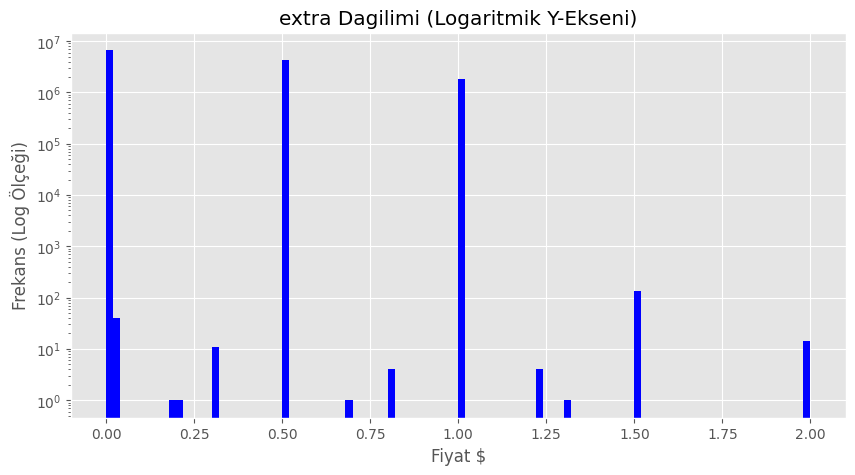

In [68]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['extra'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('extra Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

In [69]:
df["extra"].max()

np.float64(2.0)

In [70]:
df["extra"].min()

np.float64(0.0)

In [71]:
df["extra"].median()

np.float64(0.0)

Sonuç: extra son haline getirildi!

### 2.3 mta_tax

In [72]:
indexes = df[df["mta_tax"] < 0].index
df.drop(index=indexes, inplace=True)

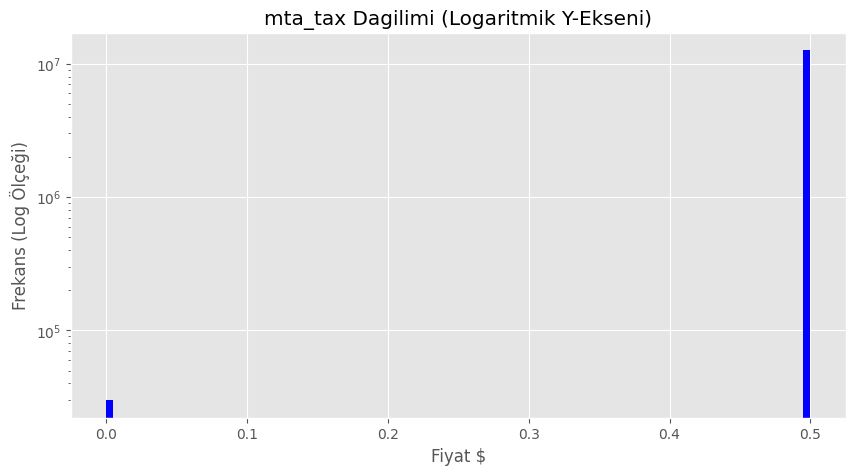

In [73]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['mta_tax'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('mta_tax Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [74]:
df["mta_tax"].median()

np.float64(0.5)

Grafikte sadece 2 çubuk var ve belli bir dağılım göstermediğinden IQR ve MAD kullanamam. value_counts() kullanacağım.

In [75]:
df["mta_tax"].value_counts()

mta_tax
0.5    12625453
0.0       29938
Name: count, dtype: int64

İzlenim: Elde sadece iki farklı veri var ve zaten negatif değerleri temizlemiş idik. Sonuç: İşleme gerek yok!

### 2.4 tip_amount

In [76]:
indexes = df[df["tip_amount"] < 0].index
df.drop(index=indexes, inplace=True)

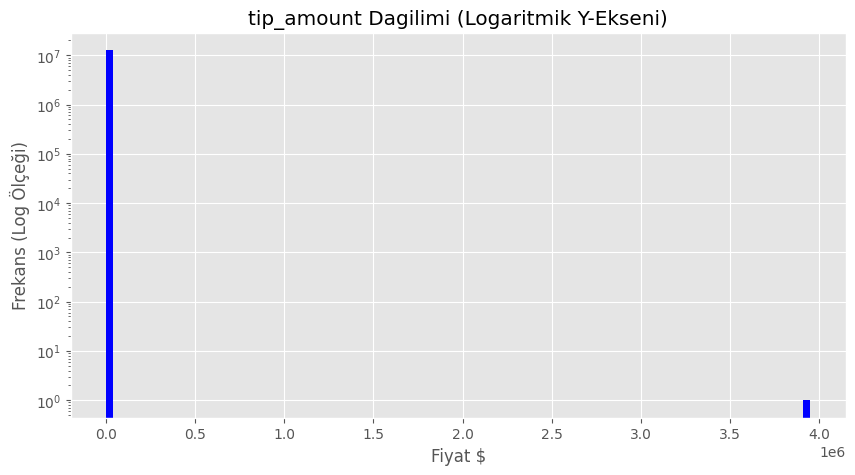

In [77]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tip_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('tip_amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [78]:
df[df["tip_amount"] > (3.5 * 1e6)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
7524351,2015-01-18 19:24:15,2015-01-18 19:51:55,1,5.32,1,249,37,1,22.0,0.0,0.5,3950588.8,0.0,0.3,3950611.6


In [79]:
indexes = df[df["tip_amount"] > (3.5 * 1e6)].index
df.drop(index=indexes, inplace=True)

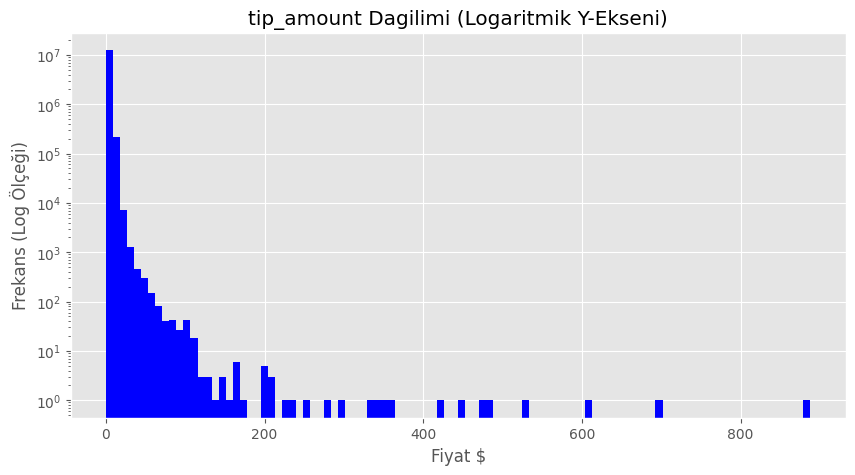

In [80]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tip_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('tip_amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [81]:
df["tip_amount"].median()

np.float64(1.0)

In [82]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["tip_amount"].quantile(0.25)
Q3 = df["tip_amount"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 0.0, Q3: 2.07, IQR: 2.07
Lower Bound: -3.1049999999999995, Upper Bound: 5.174999999999999


In [83]:
# Lets see the outliers
df[(df["tip_amount"] < lower_bound) | (df["tip_amount"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
25,2015-01-01 00:44:34,2015-01-01 01:16:15,1,8.80,1,142,65,1,30.5,0.5,0.5,7.95,0.00,0.0,39.75
37,2015-01-01 00:45:13,2015-01-01 00:55:42,1,1.80,1,162,141,1,9.2,0.5,0.5,5.88,0.00,0.0,16.38
43,2015-01-01 00:54:32,2015-01-01 01:30:34,1,7.64,1,236,256,1,28.0,0.5,0.5,5.70,0.00,0.3,35.00
87,2015-01-01 00:11:30,2015-01-01 00:44:10,6,4.91,1,48,68,1,22.5,0.5,0.5,10.00,0.00,0.3,33.80
251,2015-01-01 00:35:05,2015-01-01 01:02:29,1,8.20,1,90,181,1,27.5,0.5,0.5,7.20,0.00,0.0,36.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12740919,2015-01-31 23:34:53,2015-02-01 00:11:12,1,5.30,1,112,90,1,25.0,0.5,0.5,5.25,0.00,0.3,31.55
12740920,2015-01-31 23:15:53,2015-01-31 23:56:09,2,5.60,1,106,90,1,27.0,0.5,0.5,5.65,0.00,0.3,33.95
12740924,2015-01-31 23:05:21,2015-01-31 23:30:27,1,9.70,1,138,238,1,30.0,0.5,0.5,5.80,5.33,0.3,42.43
12741009,2015-01-31 23:19:19,2015-02-01 00:15:08,3,13.00,1,163,220,1,49.5,0.5,0.5,15.00,4.88,0.3,70.68


In [84]:
percentage = 100 * (617301 / len(df))
print("IQR outliers yüzdesi", percentage)

IQR outliers yüzdesi 4.877771447580833


İzlenim: Sol tarafta yığılma fazla olduğundan IQR 10 dolar gibi değerleri outliers sayıyor. Farklı methodlar gerekecek...

In [85]:
df["tip_amount"].value_counts()

tip_amount
0.00     5070150
1.00     1055931
2.00      531573
1.50      340398
3.00      167726
          ...   
78.59          1
35.13          1
20.86          1
49.76          1
96.00          1
Name: count, Length: 3353, dtype: int64

Normalde gelişmiş Z skoru için eşik değer 3.5 alınır ama eğerr ben bu değeri alırsam verilerin çoğu solda biriktiğinden sağ tarafta büyük bir veri kaybı yaşarım. Bunun için bu sütunu normalize edilmiş kopyasını oluşturacağım.

In [86]:
# Median Absolute Deviation for tip_amount
df["tip_amount_normalize"] = np.log1p(df["tip_amount"])
general_median = df["tip_amount_normalize"].median()
sapmalar = (df["tip_amount_normalize"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_tip_amount_normalize"] = (0.6745 * (df["tip_amount_normalize"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.875469,0.177417
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,1.360977,0.649863
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,1.214913,0.507729
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,1.199965,0.493183
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.900161,0.201445
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.623341,0.905169
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,1.945910,1.219061


In [87]:
df[df["advanced_zscore_for_tip_amount_normalize"] > 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize
14312,2015-01-01 00:52:01,2015-01-01 01:03:53,1,2.60,1,146,112,1,11.0,0.5,0.5,100.00,0.00,0.0,112.30,4.615121,3.816464
24218,2015-01-01 00:19:23,2015-01-01 00:39:57,2,4.88,1,45,143,1,18.5,0.5,0.5,80.00,0.00,0.3,99.80,4.394449,3.601729
47036,2015-01-01 01:12:38,2015-01-01 01:22:34,1,2.90,1,148,189,1,11.2,0.5,0.5,100.00,0.00,0.0,112.50,4.615121,3.816464
58226,2015-01-01 01:59:32,2015-01-01 02:12:32,1,1.70,1,186,163,1,9.7,0.5,0.5,100.00,0.00,0.0,111.00,4.615121,3.816464
75863,2015-01-01 02:23:15,2015-01-01 02:23:28,1,1.10,1,265,265,1,2.5,0.5,0.5,163.00,0.00,0.0,166.80,5.099866,4.288169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12302130,2015-01-31 03:48:42,2015-01-31 04:21:41,1,8.20,1,158,61,1,29.0,0.5,0.5,100.00,0.00,0.3,130.30,4.615121,3.816464
12317266,2015-01-31 05:28:52,2015-01-31 05:32:20,1,2.00,1,265,265,1,7.5,0.5,0.5,96.00,0.00,0.3,104.80,4.574711,3.777141
12410081,2015-01-31 12:22:23,2015-01-31 12:37:16,1,2.70,1,238,42,1,12.5,0.0,0.5,78.59,0.00,0.3,91.89,4.376888,3.584641
12460305,2015-01-31 13:03:14,2015-01-31 13:18:06,1,1.04,1,229,163,1,10.5,0.0,0.5,340.02,0.00,0.3,351.32,5.831941,5.000549


In [88]:
percentage = 100 * (205/len(df))
print("MAD outliers yüzdesi", percentage)

MAD outliers yüzdesi 0.001619863157121195


Fikir: Eğer yolcu çok fazla yol gitmişse 100 folar gibi bir bahşiş belki bırakabilir. bahsis_per_fare incelemek lazım.

In [89]:
df["bahsis_per_fare"] = df["tip_amount"] / df["fare_amount"]
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.875469,0.177417,0.245614
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,1.360977,0.649863,0.219697
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,1.214913,0.507729,0.289024
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,1.199965,0.493183,0.290000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.900161,0.201445,0.243333
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.623341,0.905169,0.271333
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,1.945910,1.219061,0.184615


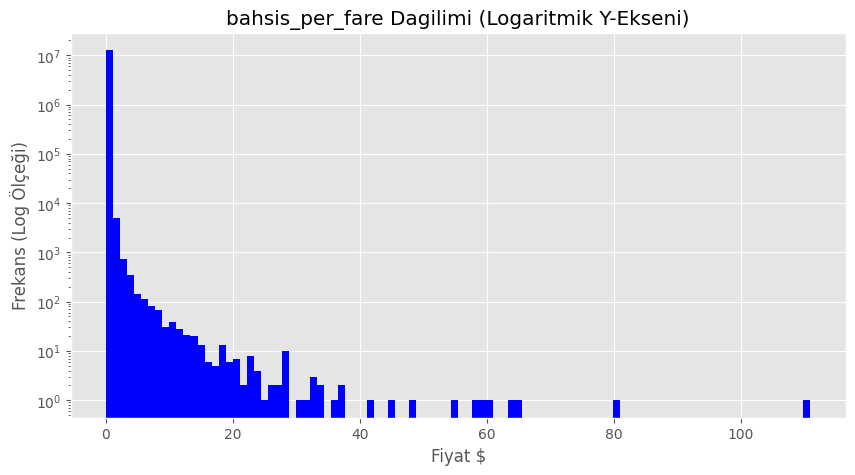

In [90]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['bahsis_per_fare'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('bahsis_per_fare Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [91]:
df[df["bahsis_per_fare"] > 100]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare
9149066,2015-01-22 21:58:47,2015-01-22 22:07:14,2,1.9,1,186,113,1,8.0,0.5,0.5,888.2,0.0,0.3,897.5,6.790322,5.933148,111.025


In [92]:
df["bahsis_per_fare"].median()

np.float64(0.15151515151515152)

In [93]:
df[df["bahsis_per_fare"] > 40]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare
75863,2015-01-01 02:23:15,2015-01-01 02:23:28,1,1.10,1,265,265,1,2.5,0.5,0.5,163.00,0.0,0.0,166.80,5.099866,4.288169,65.200000
1191617,2015-01-04 03:22:26,2015-01-04 03:31:04,1,1.40,1,249,79,1,7.5,0.5,0.5,606.57,0.0,0.0,615.37,6.409467,5.562539,80.876000
1204232,2015-01-04 05:39:20,2015-01-04 05:39:33,1,19.40,1,265,265,1,2.5,0.5,0.5,152.00,0.0,0.0,155.80,5.030438,4.220608,60.800000
1489041,2015-01-05 06:37:57,2015-01-05 06:38:00,1,44.20,1,265,265,1,2.5,0.0,0.5,160.00,0.0,0.3,163.30,5.081404,4.270203,64.000000
2230040,2015-01-07 03:44:00,2015-01-07 03:44:01,1,2.90,1,1,1,1,2.5,0.5,0.5,105.00,0.0,0.3,108.80,4.663439,3.863482,42.000000
3680480,2015-01-10 10:41:34,2015-01-10 10:50:51,1,1.37,1,234,246,1,8.0,0.0,0.5,471.18,0.0,0.3,479.98,6.157360,5.317214,58.897500
4486278,2015-01-12 02:30:42,2015-01-12 02:31:39,5,0.32,1,216,216,1,3.0,0.5,0.5,146.11,0.0,0.3,150.41,4.991181,4.182407,48.703333
6222910,2015-01-16 00:42:46,2015-01-16 00:43:02,1,27.00,1,265,265,1,2.5,0.5,0.5,147.00,0.0,0.3,150.80,4.997212,4.188276,58.800000
9149066,2015-01-22 21:58:47,2015-01-22 22:07:14,2,1.90,1,186,113,1,8.0,0.5,0.5,888.20,0.0,0.3,897.50,6.790322,5.933148,111.025000
9711947,2015-01-24 00:56:30,2015-01-24 01:03:21,1,1.10,1,162,186,1,6.5,0.5,0.5,357.36,0.0,0.3,365.16,5.881538,5.048812,54.978462


In [94]:
df[(df["bahsis_per_fare"] > 20) & (df["bahsis_per_fare"] < 40)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare
924322,2015-01-03 14:52:10,2015-01-03 17:23:02,1,94.70,1,132,265,1,26.0,0.0,0.5,528.55,0.00,0.0,555.35,6.272028,5.428796,20.328846
1084999,2015-01-03 21:17:44,2015-01-03 21:17:49,1,0.90,1,90,90,1,2.5,0.5,0.5,56.20,0.00,0.0,60.00,4.046554,3.263193,22.480000
1099729,2015-01-03 22:35:29,2015-01-03 22:35:33,1,18.30,1,265,265,1,2.5,0.5,0.5,70.00,0.00,0.0,73.80,4.262680,3.473504,28.000000
1195854,2015-01-04 04:48:18,2015-01-04 04:59:53,1,3.30,1,50,125,1,12.5,0.5,0.5,420.00,0.00,0.0,433.80,6.042633,5.205573,33.600000
1803337,2015-01-05 22:42:25,2015-01-05 22:42:28,1,0.04,1,264,265,1,2.5,0.5,0.5,81.20,0.00,0.3,85.00,4.409155,3.616039,32.480000
2183487,2015-01-06 22:38:24,2015-01-06 22:38:26,1,0.02,1,264,265,1,2.5,0.5,0.5,71.20,0.00,0.3,75.00,4.279440,3.489814,28.480000
2373736,2015-01-07 12:19:14,2015-01-07 12:22:24,1,0.31,1,143,142,1,4.0,0.0,0.5,111.00,0.00,0.3,115.80,4.718499,3.917061,27.750000
3070920,2015-01-08 23:51:10,2015-01-08 23:54:10,1,0.60,1,152,116,1,4.5,0.5,0.5,93.18,0.00,0.3,98.98,4.545208,3.748432,20.706667
3313282,2015-01-09 15:24:38,2015-01-09 16:34:36,1,12.80,1,264,264,1,2.5,1.0,0.5,54.00,0.00,0.3,58.30,4.007333,3.225027,21.600000
3594973,2015-01-10 02:14:54,2015-01-10 02:24:26,1,2.70,1,107,50,1,10.0,0.5,0.5,239.07,0.00,0.3,250.37,5.480931,4.658981,23.907000


In [95]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["bahsis_per_fare"].quantile(0.25)
Q3 = df["bahsis_per_fare"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 0.0, Q3: 0.22166666666666668, IQR: 0.22166666666666668
Lower Bound: -0.3325, Upper Bound: 0.5541666666666667


In [96]:
# Lets see the outliers
df[(df["bahsis_per_fare"] < lower_bound) | (df["bahsis_per_fare"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare
37,2015-01-01 00:45:13,2015-01-01 00:55:42,1,1.8,1,162,141,1,9.2,0.5,0.5,5.88,0.0,0.0,16.38,1.928619,1.202235,0.639130
286,2015-01-01 00:49:44,2015-01-01 00:51:56,1,0.5,1,107,170,1,3.2,0.5,0.5,2.00,0.0,0.0,6.50,1.098612,0.394557,0.625000
676,2015-01-01 00:43:23,2015-01-01 00:45:37,2,0.3,1,48,48,1,3.2,0.5,0.5,5.00,0.0,0.0,9.50,1.791759,1.069057,1.562500
1175,2015-01-01 00:45:07,2015-01-01 01:22:17,1,6.6,1,100,17,1,27.5,0.5,0.5,20.00,0.0,0.0,48.80,3.044522,2.288118,0.727273
1224,2015-01-01 00:46:04,2015-01-01 00:59:04,2,2.1,1,80,225,1,10.5,0.5,0.5,8.00,0.0,0.0,19.80,2.197225,1.463614,0.761905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12739111,2015-01-31 23:48:58,2015-02-01 00:00:15,2,1.6,1,186,79,1,9.0,0.5,0.5,5.00,0.0,0.3,15.30,1.791759,1.069057,0.555556
12739526,2015-01-31 23:47:42,2015-01-31 23:56:30,2,0.4,1,148,148,1,7.0,0.5,0.5,4.50,0.0,0.3,12.80,1.704748,0.984387,0.642857
12739832,2015-01-31 23:01:43,2015-01-31 23:46:31,1,7.6,1,68,37,1,33.5,0.5,0.5,22.46,0.0,0.3,57.26,3.155297,2.395912,0.670448
12740568,2015-01-31 23:50:12,2015-02-01 00:00:56,1,1.1,1,90,234,1,8.0,0.5,0.5,5.00,0.0,0.3,14.30,1.791759,1.069057,0.625000


In [97]:
percentage = 100 * (29392 / len(df))
print("IQR outliers yüzdesi", percentage)

IQR outliers yüzdesi 0.2322488678736886


IQR outliers hesabı gerçekler ile uyuşmuyor!

Normalde gelişmiş Z skoru için eşik değer 3.5 alınır ama eğerr ben bu değeri alırsam verilerin çoğu solda biriktiğinden sağ tarafta büyük bir veri kaybı yaşarım. Bunun için bu sütunu normalize edilmiş kopyasını oluşturacağım.

In [98]:
# Median Absolute Deviation for bahsis_per_fare
df["bahsis_per_fare_normalize"] = np.log1p(df["bahsis_per_fare"])
general_median = df["bahsis_per_fare_normalize"].median()
sapmalar = (df["bahsis_per_fare_normalize"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_bahsis_per_fare_normalize"] = (0.6745 * (df["bahsis_per_fare_normalize"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.875469,0.177417,0.245614,0.219629,0.559960
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000,0.000000,1.005708
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,1.360977,0.649863,0.219697,0.198602,0.410071
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,1.214913,0.507729,0.289024,0.253886,0.804169
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000,0.000000,1.005708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,1.199965,0.493183,0.290000,0.254642,0.809562
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.900161,0.201445,0.243333,0.217796,0.546896
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.623341,0.905169,0.271333,0.240066,0.705654
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,1.945910,1.219061,0.184615,0.169418,0.202024


In [99]:
df[df["advanced_zscore_for_bahsis_per_fare_normalize"] > 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize
676,2015-01-01 00:43:23,2015-01-01 00:45:37,2,0.30,1,48,48,1,3.2,0.5,0.5,5.00,0.0,0.0,9.50,1.791759,1.069057,1.562500,0.940983,5.702288
1229,2015-01-01 00:05:37,2015-01-01 00:10:21,1,0.90,1,79,4,1,5.2,0.5,0.5,5.00,0.0,0.0,11.50,1.791759,1.069057,0.961538,0.673729,3.797110
1497,2015-01-01 00:12:54,2015-01-01 00:20:09,2,0.97,1,234,90,1,6.5,0.5,0.5,10.08,0.0,0.3,17.88,2.405142,1.665938,1.550769,0.936395,5.669579
2101,2015-01-01 00:47:14,2015-01-01 01:11:36,2,2.80,1,163,113,1,16.5,0.5,0.5,20.00,0.0,0.0,37.80,3.044522,2.288118,1.212121,0.793952,4.654143
3471,2015-01-01 00:55:32,2015-01-01 00:59:18,1,0.52,1,79,113,1,4.5,0.5,0.5,6.26,0.0,0.3,12.06,1.982380,1.254549,1.391111,0.871758,5.208802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12736958,2015-01-31 23:42:47,2015-02-01 00:16:37,1,7.10,1,239,256,1,28.5,0.5,0.5,40.40,0.0,0.3,70.20,3.723281,2.948616,1.417544,0.882752,5.287174
12737220,2015-01-31 23:21:28,2015-01-31 23:24:17,1,0.60,1,170,100,1,4.5,0.5,0.5,6.00,0.0,0.3,11.80,1.945910,1.219061,1.333333,0.847298,5.034431
12737268,2015-01-31 23:00:40,2015-01-31 23:12:31,4,1.40,1,249,79,1,9.0,0.5,0.5,10.00,0.0,0.3,20.30,2.397895,1.658887,1.111111,0.747214,4.320965
12738248,2015-01-31 23:06:06,2015-01-31 23:20:29,1,2.30,1,90,231,1,11.5,0.5,0.5,15.00,0.0,0.3,27.80,2.772589,2.023500,1.304348,0.834798,4.945321


In [100]:
percentage = 100 * (9819 / len(df))
print("MAD outliers yüzdesi", percentage)

MAD outliers yüzdesi 0.07758749434035617


İzlenim: MAD hesabı Outliers' a göre daha mantıklı.

In [101]:
df[df["advanced_zscore_for_bahsis_per_fare_normalize"] > 3.5]["tip_amount"].max()

np.float64(888.2)

In [102]:
df[(df["tip_amount"] > 200) & (df["advanced_zscore_for_bahsis_per_fare_normalize"] <= 3.5)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize


In [103]:
df[df["tip_amount"] > 200]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize
367025,2015-01-01 22:36:15,2015-01-01 22:50:55,1,2.20,1,163,68,1,12.0,0.5,0.5,212.11,0.0,0.0,225.41,5.361808,4.543064,17.675833,2.927230,19.861664
924322,2015-01-03 14:52:10,2015-01-03 17:23:02,1,94.70,1,132,265,1,26.0,0.0,0.5,528.55,0.0,0.0,555.35,6.272028,5.428796,20.328846,3.060060,20.808571
1117489,2015-01-03 23:19:50,2015-01-03 23:34:23,6,5.18,1,129,28,1,16.5,0.5,0.5,227.77,0.0,0.3,245.57,5.432717,4.612065,13.804242,2.694914,18.205547
1191617,2015-01-04 03:22:26,2015-01-04 03:31:04,1,1.40,1,249,79,1,7.5,0.5,0.5,606.57,0.0,0.0,615.37,6.409467,5.562539,80.876000,4.405206,30.397721
1195854,2015-01-04 04:48:18,2015-01-04 04:59:53,1,3.30,1,50,125,1,12.5,0.5,0.5,420.00,0.0,0.0,433.80,6.042633,5.205573,33.600000,3.543854,24.257392
3594973,2015-01-10 02:14:54,2015-01-10 02:24:26,1,2.70,1,107,50,1,10.0,0.5,0.5,239.07,0.0,0.3,250.37,5.480931,4.658981,23.907000,3.215149,21.914151
3680480,2015-01-10 10:41:34,2015-01-10 10:50:51,1,1.37,1,234,246,1,8.0,0.0,0.5,471.18,0.0,0.3,479.98,6.157360,5.317214,58.897500,4.092635,28.169492
4344769,2015-01-11 17:06:04,2015-01-11 17:16:38,1,1.07,1,163,229,1,8.0,0.0,0.5,255.50,0.0,0.3,264.30,5.547129,4.723399,31.937500,3.494612,23.906361
6080674,2015-01-15 19:31:16,2015-01-15 19:57:01,2,10.60,1,265,169,1,31.5,1.0,0.5,200.06,0.0,0.3,233.36,5.303603,4.486425,6.351111,1.994851,13.215006
6197628,2015-01-15 23:49:10,2015-01-15 23:49:56,1,8.10,2,227,227,1,52.0,0.0,0.5,450.00,0.0,0.3,502.80,6.111467,5.272555,8.653846,2.267356,15.157615


In [104]:
df[df["advanced_zscore_for_bahsis_per_fare_normalize"] < 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.875469,0.177417,0.245614,0.219629,0.559960
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000,0.000000,1.005708
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,1.360977,0.649863,0.219697,0.198602,0.410071
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,1.214913,0.507729,0.289024,0.253886,0.804169
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000,0.000000,1.005708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,1.199965,0.493183,0.290000,0.254642,0.809562
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.900161,0.201445,0.243333,0.217796,0.546896
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.623341,0.905169,0.271333,0.240066,0.705654
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,1.945910,1.219061,0.184615,0.169418,0.202024


In [105]:
indexes = df[df["advanced_zscore_for_bahsis_per_fare_normalize"] > 3.5].index
df.drop(index=indexes, inplace=True)

In [106]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'tip_amount_normalize', 'advanced_zscore_for_tip_amount_normalize',
       'bahsis_per_fare', 'bahsis_per_fare_normalize',
       'advanced_zscore_for_bahsis_per_fare_normalize'],
      dtype='object')

In [ ]:
df.drop(columns=["fare_per_distance", "tip_amount_normalize", 
                  "advanced_zscore_for_tip_amount_normalize", 
                  "bahsis_per_fare", "bahsis_per_fare_normalize", 
                  "advanced_zscore_for_bahsis_per_fare_normalize"], inplace=True)

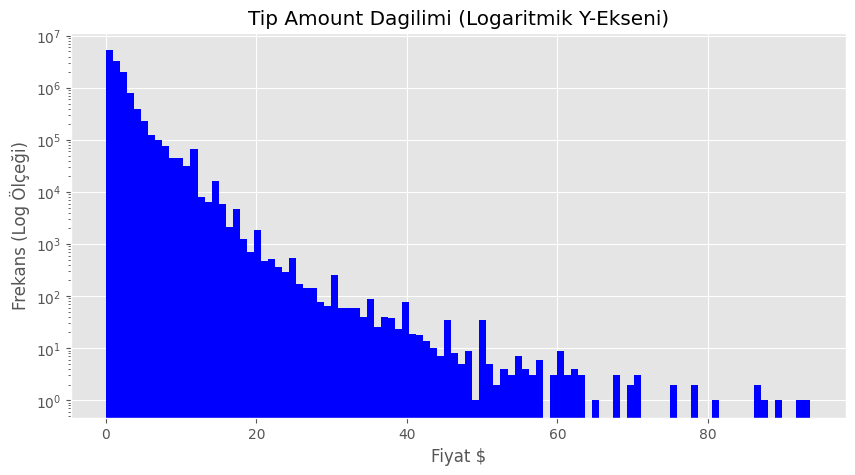

In [109]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tip_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Tip Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

In [110]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.875469,0.177417,0.245614,0.219629,0.559960
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000,0.000000,1.005708
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,1.360977,0.649863,0.219697,0.198602,0.410071
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,1.214913,0.507729,0.289024,0.253886,0.804169
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.000000,0.674500,0.000000,0.000000,1.005708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,1.199965,0.493183,0.290000,0.254642,0.809562
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.900161,0.201445,0.243333,0.217796,0.546896
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.623341,0.905169,0.271333,0.240066,0.705654
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,1.945910,1.219061,0.184615,0.169418,0.202024


In [111]:
df["tip_amount"].max()

np.float64(93.65)

In [112]:
df[df["tip_amount"] > 90]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_amount_normalize,advanced_zscore_for_tip_amount_normalize,bahsis_per_fare,bahsis_per_fare_normalize,advanced_zscore_for_bahsis_per_fare_normalize
6678640,2015-01-16 23:02:43,2015-01-17 00:31:37,3,69.0,4,45,265,1,306.5,0.5,0.5,92.34,0.0,0.3,400.14,4.536249,3.739714,0.301272,0.263343,0.871584
11973113,2015-01-30 15:46:48,2015-01-30 15:58:00,1,11.2,5,265,265,1,312.0,0.0,0.0,93.65,0.0,0.3,405.95,4.550186,3.753276,0.300160,0.262488,0.865489


In [113]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'tip_amount_normalize', 'advanced_zscore_for_tip_amount_normalize',
       'bahsis_per_fare', 'bahsis_per_fare_normalize',
       'advanced_zscore_for_bahsis_per_fare_normalize'],
      dtype='object')

In [114]:
df.drop(columns=["tip_amount_normalize", 
                 "advanced_zscore_for_tip_amount_normalize", 
                 "bahsis_per_fare", "bahsis_per_fare_normalize", 
                 "advanced_zscore_for_bahsis_per_fare_normalize"], inplace=True)

In [115]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80


### 2.5 tolls_amount

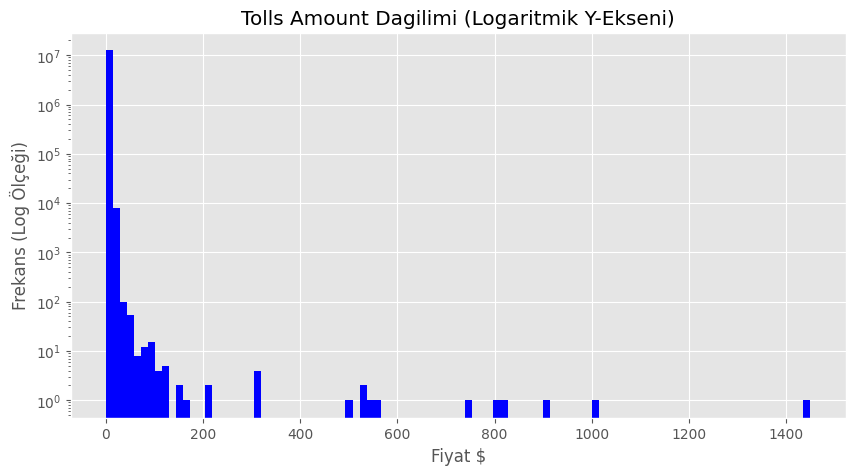

In [116]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tolls_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Tolls Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [117]:
df[df["tolls_amount"] > 200]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
813820,2015-01-03 08:23:16,2015-01-03 08:36:15,4,6.1,2,230,157,3,52.0,0.0,0.5,0.0,533.00,0.0,585.80
2077006,2015-01-06 18:27:38,2015-01-06 19:04:04,2,18.5,2,264,264,2,52.0,0.0,0.5,0.0,1450.09,0.3,1502.89
2161914,2015-01-06 21:51:11,2015-01-06 22:27:35,2,19.8,2,132,249,2,52.0,0.0,0.5,0.0,805.09,0.3,857.89
2514732,2015-01-07 19:11:04,2015-01-07 19:12:23,1,11.5,5,264,264,2,36.0,0.0,0.0,0.0,533.00,0.3,569.30
3327630,2015-01-09 16:58:15,2015-01-09 17:24:04,1,9.9,1,170,138,3,30.0,1.0,0.5,0.0,305.41,0.3,337.21
4185833,2015-01-11 09:13:36,2015-01-11 09:39:08,1,16.7,2,264,264,3,52.0,0.0,0.5,0.0,505.83,0.3,558.63
4359729,2015-01-11 17:17:22,2015-01-11 18:05:56,1,19.1,2,132,68,2,52.0,0.0,0.5,0.0,315.33,0.3,368.13
6447080,2015-01-16 15:03:52,2015-01-16 15:53:41,1,13.1,1,87,138,2,43.5,0.0,0.5,0.0,540.33,0.3,584.63
7937676,2015-01-20 00:22:37,2015-01-20 00:35:10,2,7.6,1,138,262,4,22.5,0.5,0.5,0.0,750.00,0.3,773.80
7957500,2015-01-20 06:49:26,2015-01-20 07:19:02,1,17.8,2,211,132,4,52.0,0.0,0.5,0.0,305.38,0.3,358.18


In [118]:
indexes = df[df["tolls_amount"] > 200].index
df.drop(index=indexes, inplace=True)

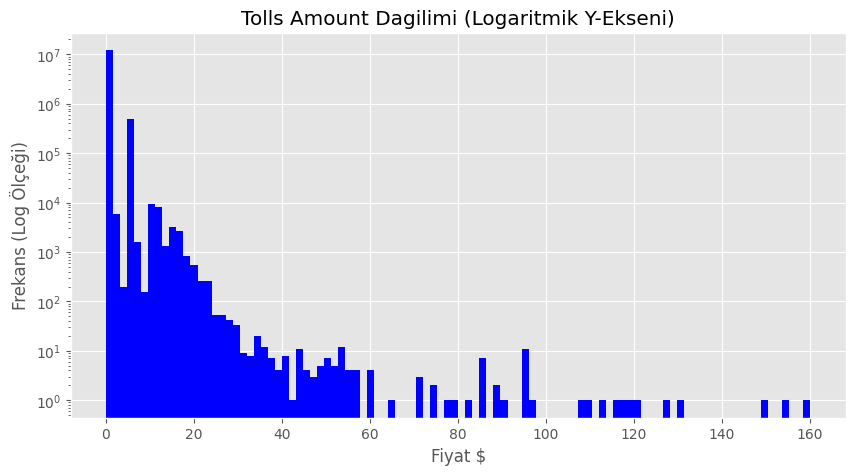

In [119]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tolls_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Tolls Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [120]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["tolls_amount"].quantile(0.25)
Q3 = df["tolls_amount"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 0.0, Q3: 0.0, IQR: 0.0
Lower Bound: 0.0, Upper Bound: 0.0


In [121]:
# Lets see the outliers
df[(df["fare_amount"] < lower_bound) | (df["fare_amount"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80


Verilerin çoğunluğu sıfırda biriktiğinde IQR afallıyor!

In [122]:
# Median Absolute Deviation for tolls_amount
df["tolls_amount_normalize"] = np.log1p(df["tolls_amount"])
general_median = df["tolls_amount_normalize"].median()
sapmalar = (df["tolls_amount_normalize"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_tolls_amount_normalize"] = (0.6745 * (df["tolls_amount_normalize"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tolls_amount_normalize,advanced_zscore_for_tolls_amount_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.0,NaN
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.0,NaN
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,0.0,NaN
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,0.0,NaN
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,0.0,NaN
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.0,NaN
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,0.0,NaN
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,0.0,NaN


In [123]:
MAD

np.float64(0.0)

Verilerin büyük çoğunluğu sıfırda toplandığı için MAD de sıfır geldi

In [124]:
df["tolls_amount"].value_counts().head(20)

tolls_amount
0.00     12111602
5.33       497320
11.75        7754
9.75         5280
2.44         5180
10.66        3442
7.50         1076
15.99         822
17.08         724
16.75         661
11.00         611
14.75         522
2.00          431
15.75         384
15.00         378
15.08         331
13.75         291
17.75         257
16.00         245
14.00         206
Name: count, dtype: int64

In [125]:
df[df["tolls_amount"] >= 60]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tolls_amount_normalize,advanced_zscore_for_tolls_amount_normalize
291703,2015-01-01 17:45:59,2015-01-01 18:19:34,3,9.60,1,230,40,2,33.0,1.0,0.5,0.0,77.55,0.0,112.35,4.363735,inf
926895,2015-01-03 14:05:00,2015-01-03 14:50:12,1,19.10,2,137,10,2,52.0,0.0,0.5,0.0,95.33,0.0,148.13,4.567780,inf
1408804,2015-01-04 20:54:00,2015-01-04 21:31:35,1,17.80,2,132,234,3,52.0,0.0,0.5,0.0,60.34,0.0,113.14,4.116432,inf
1677406,2015-01-05 16:48:42,2015-01-05 17:12:51,2,7.80,1,264,264,3,26.0,1.0,0.5,0.0,85.33,0.3,113.13,4.458177,inf
1862096,2015-01-06 07:59:38,2015-01-06 08:37:50,1,18.20,2,132,42,2,52.0,0.0,0.5,0.0,60.00,0.3,112.80,4.110874,inf
1869896,2015-01-06 07:29:10,2015-01-06 07:48:30,1,13.28,3,249,1,2,54.0,0.0,0.0,0.0,130.00,0.3,184.30,4.875197,inf
2562642,2015-01-07 20:34:04,2015-01-07 20:59:18,1,15.00,1,231,210,3,41.5,0.5,0.5,0.0,71.33,0.3,114.13,4.281239,inf
3121513,2015-01-09 04:39:54,2015-01-09 05:09:06,1,20.10,3,161,1,3,71.5,0.5,0.0,0.0,73.75,0.3,146.05,4.314149,inf
3342244,2015-01-09 17:30:47,2015-01-09 17:48:16,4,0.50,1,163,202,2,2.5,1.0,0.5,0.0,107.90,0.3,112.20,4.690430,inf
4154887,2015-01-11 05:05:12,2015-01-11 05:18:55,1,4.70,5,246,265,3,60.0,0.0,0.0,0.0,79.50,0.3,139.80,4.388257,inf


In [126]:
indexes = df[df["tolls_amount"] >= 60].index
df.drop(index=indexes, inplace=True)

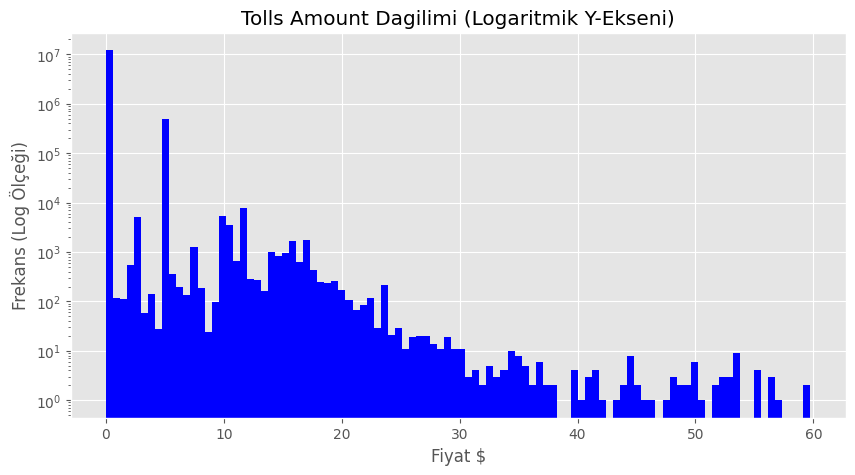

In [127]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tolls_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Tolls Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [128]:
df["tolls_amount"].quantile(0.999)

np.float64(11.75)

In [129]:
df[(df["tolls_amount"] > 20) & (df["fare_amount"] < df["tolls_amount"])]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tolls_amount_normalize,advanced_zscore_for_tolls_amount_normalize
112501,2015-01-01 04:25:00,2015-01-01 04:57:31,2,3.80,1,234,257,3,2.5,0.5,0.5,0.0,41.44,0.0,45.24,3.748091,inf
130611,2015-01-01 05:47:06,2015-01-01 06:09:27,2,5.50,1,237,17,2,2.5,0.0,0.5,0.0,23.00,0.0,26.30,3.178054,inf
161598,2015-01-01 09:36:05,2015-01-01 10:05:45,1,18.50,2,142,132,3,52.0,0.0,0.5,0.0,53.33,0.0,106.13,3.995077,inf
622593,2015-01-02 19:11:52,2015-01-02 19:26:06,1,1.80,1,234,163,2,10.0,1.0,0.5,0.0,34.24,0.0,46.04,3.562182,inf
723346,2015-01-02 23:16:12,2015-01-02 23:23:56,1,0.86,1,230,170,2,6.0,0.5,0.5,0.0,21.32,0.3,28.62,3.105483,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12304595,2015-01-31 04:12:43,2015-01-31 04:52:52,2,18.70,1,162,265,2,2.5,0.5,0.5,0.0,24.95,0.3,28.75,3.256172,inf
12333660,2015-01-31 08:56:11,2015-01-31 09:17:56,1,15.40,3,246,1,2,58.5,0.0,0.0,0.0,59.76,0.3,118.56,4.106932,inf
12386875,2015-01-31 11:53:47,2015-01-31 11:55:29,2,0.20,1,264,161,2,3.5,0.0,0.5,0.0,52.00,0.3,56.30,3.970292,inf
12514522,2015-01-31 16:27:43,2015-01-31 19:44:20,1,11.00,1,236,137,2,2.5,0.0,0.5,0.0,49.44,0.3,52.74,3.920785,inf


In [130]:
indexes = df[(df["tolls_amount"] > 20) & (df["fare_amount"] < df["tolls_amount"])].index
df.drop(index=indexes, inplace=True)

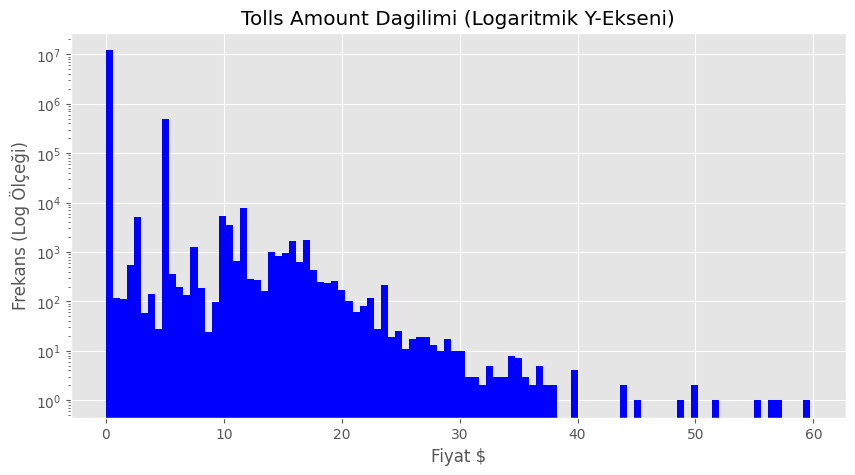

In [131]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tolls_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Tolls Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

Köprüden git gel durumunu da sayarsak 25 dolar civarını görmek zor, sınır olarak belirlenebilir mi?

In [132]:
percentage = 100 * (len(df[df["tolls_amount"] > 25]) / len(df))
print(f"25 dolardan fazla olanlarin yüzdesi", percentage)

25 dolardan fazla olanlarin yüzdesi 0.0015262445258828136


In [133]:
indexes = df[df["tolls_amount"] > 25].index
df.drop(index=indexes, inplace=True)

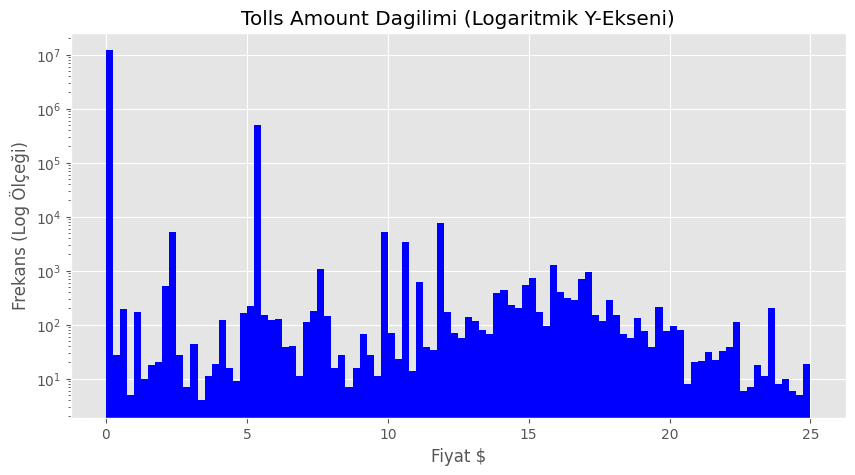

In [134]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['tolls_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Tolls Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

### 2.6 Duration

In [135]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'tolls_amount_normalize', 'advanced_zscore_for_tolls_amount_normalize'],
      dtype='object')

In [136]:
df.drop(columns=["tolls_amount_normalize", "advanced_zscore_for_tolls_amount_normalize"], inplace=True)

In [137]:
df["duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
# dakika bazında geçen süreyi yeni sütun olarak ekledim
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000


In [138]:
indexes = df[df["duration"] <= 0].index
df.drop(index=indexes, inplace=True)

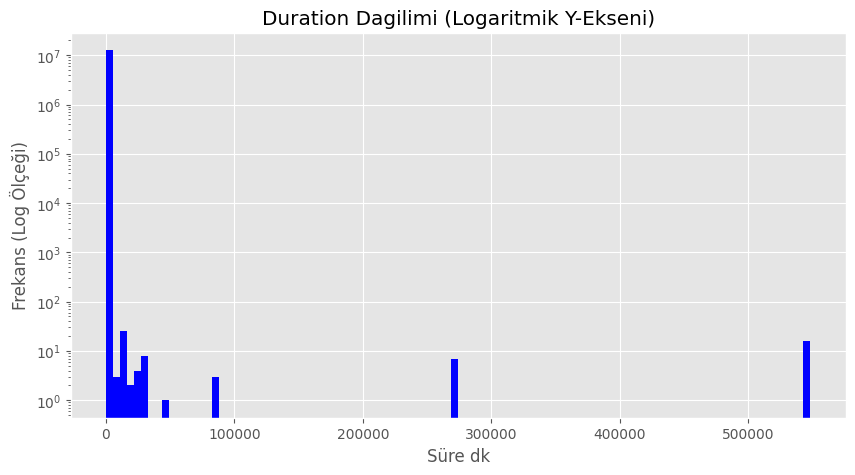

In [139]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Duration Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Süre dk')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [140]:
df[df["duration"] > 1e5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
4396958,2015-01-11 19:01:57,2015-07-18 12:02:30,1,2.4,1,264,264,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30,270300.550000
4684529,2015-01-12 15:15:32,2015-07-18 12:29:12,1,1.9,1,264,264,1,8.0,0.0,0.5,2.00,0.0,0.3,10.80,269113.666667
4684530,2015-01-12 15:15:32,2015-07-18 12:36:11,1,1.1,1,264,264,2,5.5,0.0,0.5,0.00,0.0,0.3,6.30,269120.650000
4684531,2015-01-12 15:15:32,2015-07-18 12:50:43,1,0.8,1,264,264,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30,269135.183333
4684532,2015-01-12 15:15:32,2015-07-18 13:19:31,1,0.9,1,264,264,1,5.5,0.5,0.5,1.62,0.0,0.3,8.42,269163.983333
4684533,2015-01-12 15:15:32,2015-07-18 13:34:02,1,2.3,1,264,264,1,10.0,0.5,0.5,2.20,0.0,0.3,13.50,269178.500000
4684534,2015-01-12 15:15:32,2015-07-18 13:49:03,1,3.4,1,264,264,1,13.0,0.5,0.5,2.80,0.0,0.3,17.10,269193.516667
6938581,2015-01-17 15:16:00,2016-02-02 11:26:19,1,1.6,1,264,264,2,8.0,0.0,0.5,0.00,0.0,0.3,8.80,548410.316667
6938582,2015-01-17 15:16:00,2016-02-02 11:45:33,1,1.8,1,264,264,1,8.5,0.0,0.5,1.80,0.0,0.3,11.10,548429.550000
6938583,2015-01-17 15:16:00,2016-02-02 11:57:38,1,0.5,1,264,264,2,5.0,0.0,0.5,0.00,0.0,0.3,5.80,548441.633333


In [141]:
indexes = df[df["duration"] > 1e5].index
df.drop(index=indexes, inplace=True)

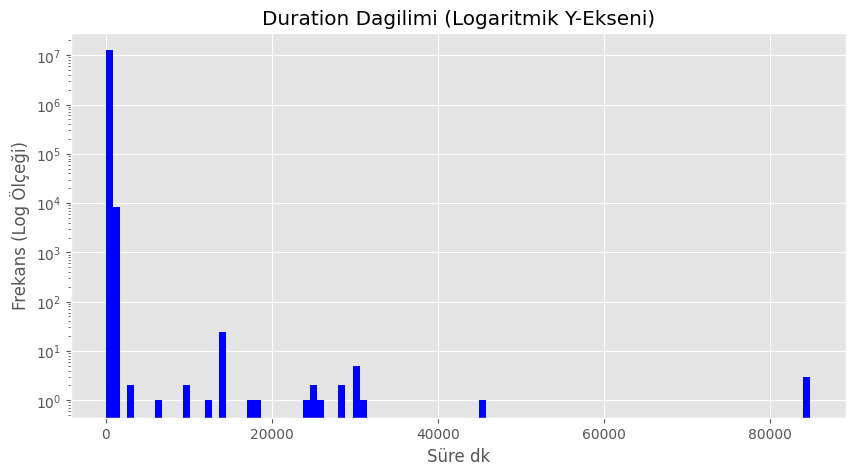

In [142]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Duration Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Süre dk')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [143]:
df[df["duration"] > 20000]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
707125,2015-01-02 23:59:22,2015-01-20 14:46:39,1,1.0,1,50,68,2,5.5,0.0,0.5,0.00,0.0,0.0,6.30,25367.283333
2660099,2015-01-08 03:14:00,2015-02-08 11:02:14,1,2.7,1,249,163,2,10.0,0.0,0.5,0.00,0.0,0.3,10.80,45108.233333
2660320,2015-01-08 03:12:05,2015-01-28 22:23:24,1,0.7,1,79,107,2,5.0,0.0,0.5,0.00,0.0,0.3,5.80,29951.316667
7084295,2015-01-17 21:33:40,2015-02-04 10:15:26,1,5.7,1,264,264,1,4.5,0.5,0.5,1.00,0.0,0.3,6.80,25241.766667
7420673,2015-01-18 15:15:50,2015-02-04 10:30:43,3,6.0,1,264,264,1,20.0,0.5,0.5,2.00,0.0,0.3,23.30,24194.883333
10405248,2015-01-25 15:16:34,2015-02-12 16:02:22,1,7.8,1,186,159,1,26.5,0.5,0.5,3.00,0.0,0.3,30.80,25965.800000
10405249,2015-01-25 15:16:34,2015-02-15 21:09:34,1,1.5,1,168,69,2,7.0,0.5,0.5,0.00,0.0,0.3,8.30,30593.000000
10409427,2015-01-25 15:16:35,2015-02-15 13:59:28,1,1.8,1,264,264,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80,30162.883333
10409428,2015-01-25 15:16:35,2015-02-15 14:08:25,2,1.4,1,264,264,1,8.0,0.0,0.5,1.76,0.0,0.3,10.56,30171.833333
10409429,2015-01-25 15:16:35,2015-02-15 14:23:06,2,0.9,1,264,264,1,5.0,0.0,0.5,1.45,0.0,0.3,7.25,30186.516667


In [144]:
indexes = df[df["duration"] > 20000].index
df.drop(index=indexes, inplace=True)

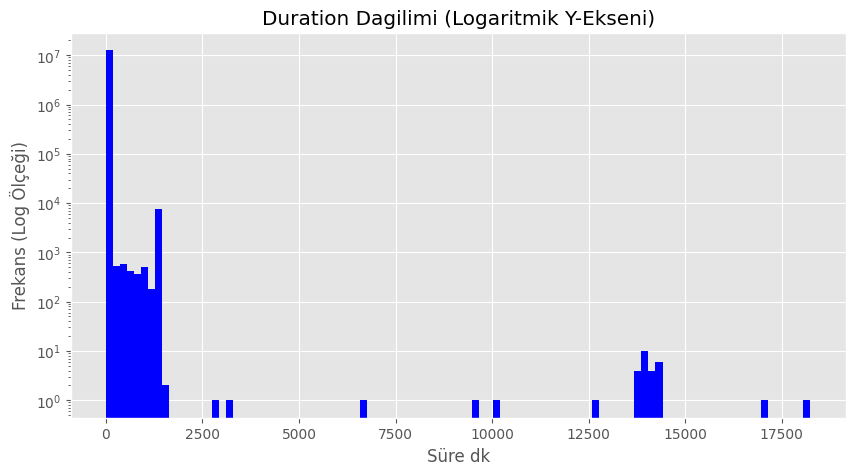

In [145]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Duration Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Süre dk')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [146]:
indexes = df[df["duration"] > 2500].index
df.drop(index=indexes, inplace=True)

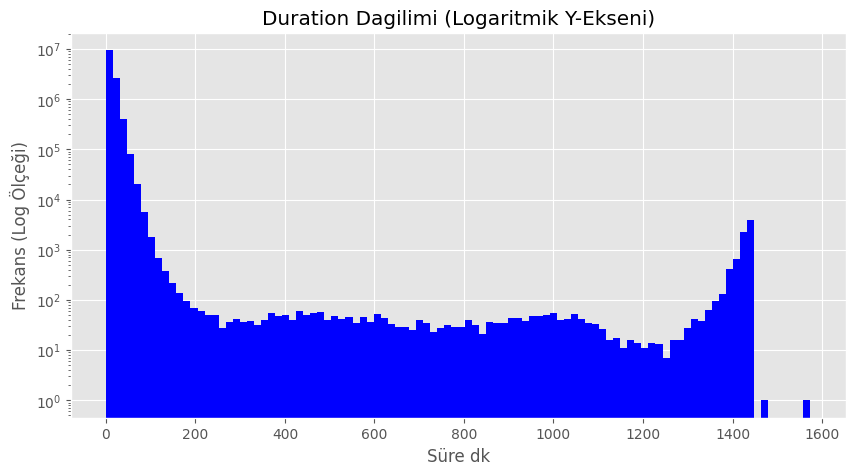

In [147]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Duration Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Süre dk')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [148]:
df[df["duration"] > 1400]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
2335,2015-01-01 00:37:12,2015-01-02 00:28:04,1,4.53,1,48,144,1,21.5,0.5,0.5,0.00,0.0,0.3,22.80,1430.866667
4350,2015-01-01 00:08:28,2015-01-02 00:00:00,1,2.78,1,231,186,1,11.0,0.5,0.5,0.00,0.0,0.3,12.30,1431.533333
4813,2015-01-01 00:35:44,2015-01-02 00:34:09,2,1.44,1,249,137,2,7.5,0.5,0.5,0.00,0.0,0.3,8.80,1438.416667
6342,2015-01-01 00:55:26,2015-01-02 00:46:38,1,1.10,1,234,113,2,6.0,0.5,0.5,0.00,0.0,0.3,7.30,1431.200000
6402,2015-01-01 00:56:33,2015-01-02 00:54:50,6,2.96,1,262,151,2,12.5,0.5,0.5,0.00,0.0,0.3,13.80,1438.283333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12734225,2015-01-31 23:10:13,2015-02-01 22:40:03,3,2.43,1,237,229,1,14.0,0.5,0.5,2.30,0.0,0.3,17.60,1409.833333
12735965,2015-01-31 23:41:19,2015-02-01 23:40:50,2,3.05,1,230,262,1,12.5,0.5,0.5,1.30,0.0,0.3,15.10,1439.516667
12736500,2015-01-31 23:47:10,2015-02-01 23:21:05,1,10.48,1,79,244,1,40.5,0.5,0.5,8.36,0.0,0.3,50.16,1413.916667
12737677,2015-01-31 23:02:45,2015-02-01 22:53:00,1,7.63,1,97,161,1,27.0,0.5,0.5,1.42,0.0,0.3,29.72,1430.250000


In [149]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["duration"].quantile(0.25)
Q3 = df["duration"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 6.166666666666667, Q3: 15.833333333333334, IQR: 9.666666666666668
Lower Bound: -8.333333333333336, Upper Bound: 30.333333333333336


In [150]:
# Lets see the outliers
df[(df["duration"] < lower_bound) | (df["duration"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
25,2015-01-01 00:44:34,2015-01-01 01:16:15,1,8.80,1,142,65,1,30.5,0.5,0.5,7.95,0.00,0.0,39.75,31.683333
43,2015-01-01 00:54:32,2015-01-01 01:30:34,1,7.64,1,236,256,1,28.0,0.5,0.5,5.70,0.00,0.3,35.00,36.033333
50,2015-01-01 00:52:49,2015-01-01 01:27:16,5,5.43,1,239,79,1,23.5,0.5,0.5,4.80,0.00,0.3,29.60,34.450000
64,2015-01-01 00:05:13,2015-01-01 00:35:59,1,6.40,1,211,226,1,24.0,0.5,0.5,5.05,0.00,0.0,30.35,30.766667
77,2015-01-01 00:35:05,2015-01-01 01:05:59,4,4.65,1,237,45,2,21.0,0.5,0.5,0.00,0.00,0.3,22.30,30.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741009,2015-01-31 23:19:19,2015-02-01 00:15:08,3,13.00,1,163,220,1,49.5,0.5,0.5,15.00,4.88,0.3,70.68,55.816667
12741015,2015-01-31 23:27:10,2015-02-01 00:07:33,1,12.72,1,114,55,1,40.5,0.5,0.5,5.00,5.33,0.3,52.13,40.383333
12741025,2015-01-31 23:30:26,2015-02-01 00:30:05,1,13.75,1,148,89,2,46.5,0.5,0.5,0.00,5.33,0.3,53.13,59.650000
12741028,2015-01-31 23:36:46,2015-02-01 00:13:32,1,8.10,1,239,129,2,30.0,0.5,0.5,0.00,0.00,0.3,31.30,36.766667


İnceleme: IQR yarım milyona yakın satırın outliers olduğunu söylüyor!

In [151]:
# Median Absolute Deviation for duration
df["duration_normalize"] = np.log1p(df["duration"])
general_median = df["duration_normalize"].median()
sapmalar = (df["duration_normalize"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_duration_normalize"] = (0.6745 * (df["duration_normalize"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,duration_normalize,advanced_zscore_for_duration_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000,1.832581,0.892056
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333,1.936341,0.728326
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333,2.758955,0.569746
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000,2.186051,0.334287
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000,1.953028,0.701994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000,2.332144,0.103755
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667,2.056258,0.539098
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333,3.112774,1.128068
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000,3.864931,2.314960


In [152]:
df[df["advanced_zscore_for_duration_normalize"] > 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,duration_normalize,advanced_zscore_for_duration_normalize
98,2015-01-01 00:30:17,2015-01-01 00:30:25,1,0.10,1,237,141,2,2.5,0.5,0.5,0.00,0.0,0.0,3.80,0.133333,0.125163,3.586336
2335,2015-01-01 00:37:12,2015-01-02 00:28:04,1,4.53,1,48,144,1,21.5,0.5,0.5,0.00,0.0,0.3,22.80,1430.866667,7.266734,7.682952
2638,2015-01-01 00:14:33,2015-01-01 00:14:42,1,0.05,1,265,264,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.150000,0.139762,3.563299
3160,2015-01-01 00:18:54,2015-01-01 02:30:04,1,2.60,1,48,188,2,11.0,0.0,0.5,0.00,0.0,0.0,11.80,131.166667,4.884064,3.923135
3288,2015-01-01 00:13:09,2015-01-01 00:13:19,1,0.02,1,151,264,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.166667,0.154151,3.540594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12736500,2015-01-31 23:47:10,2015-02-01 23:21:05,1,10.48,1,79,244,1,40.5,0.5,0.5,8.36,0.0,0.3,50.16,1413.916667,7.254826,7.664161
12737677,2015-01-31 23:02:45,2015-02-01 22:53:00,1,7.63,1,97,161,1,27.0,0.5,0.5,1.42,0.0,0.3,29.72,1430.250000,7.266303,7.682272
12738593,2015-01-31 23:01:49,2015-02-01 23:00:21,1,6.48,1,234,61,1,23.5,0.5,0.5,4.96,0.0,0.3,29.76,1438.533333,7.272074,7.691379
12739150,2015-01-31 23:45:49,2015-01-31 23:45:51,1,20.70,2,107,107,1,52.0,0.0,0.5,10.55,0.0,0.3,63.35,0.033333,0.032790,3.732100


In [153]:
df[df["advanced_zscore_for_duration_normalize"] > 3.5]["duration"].max()

np.float64(1574.25)

In [154]:
df[df["advanced_zscore_for_duration_normalize"] > 3.5]["duration"].min()

np.float64(0.016666666666666666)

In [155]:
df[df["advanced_zscore_for_duration_normalize"] > 3.5]["duration"].median()

np.float64(397.85833333333335)

Gelişmiş Z score IQR'ye göre daha az ve isabetli outliers detect etti.

In [156]:
df["duration"].quantile(0.999)

np.float64(99.0)

In [157]:
indexes = df[df["advanced_zscore_for_duration_normalize"] > 3.5].index
df.drop(index=indexes, inplace=True)

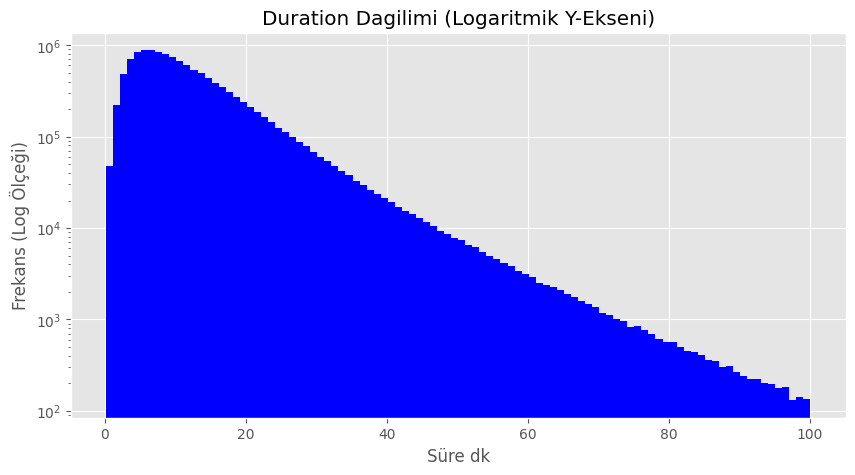

In [158]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['duration'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Duration Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Süre dk')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [159]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount', 'duration',
       'duration_normalize', 'advanced_zscore_for_duration_normalize'],
      dtype='object')

In [160]:
df.drop(columns=["duration_normalize", 
                 "advanced_zscore_for_duration_normalize"], inplace=True)

### 2.7 Passanger Count

In [161]:
df[df["passenger_count"] <= 0]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration


In [162]:
df["passenger_count"].max()

np.int64(9)

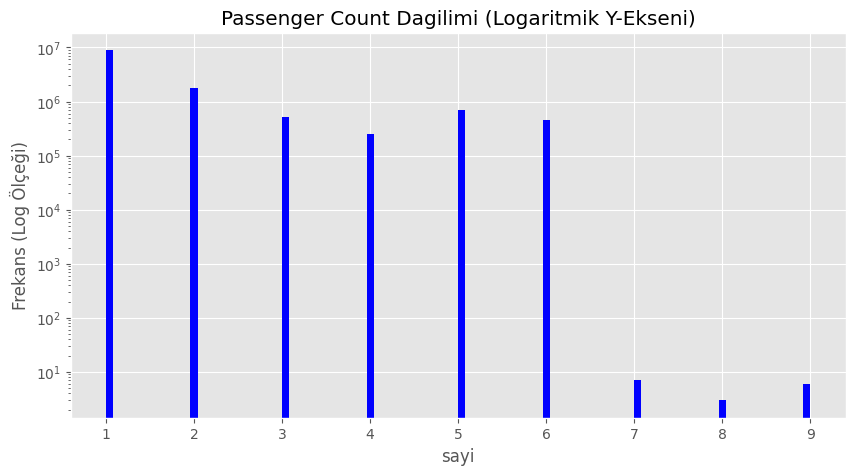

In [163]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['passenger_count'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Passenger Count Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('sayi')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin discrete dağılımını göstermektedir.

In [164]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["passenger_count"].quantile(0.25)
Q3 = df["passenger_count"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 1.0, Q3: 2.0, IQR: 1.0
Lower Bound: -0.5, Upper Bound: 3.5


In [165]:
df[df["passenger_count"] > 6]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
355153,2015-01-01 21:32:16,2015-01-01 21:42:22,7,1.40,1,158,107,1,8.5,0.5,0.5,1.95,0.00,0.0,11.75,10.100000
369909,2015-01-01 22:10:01,2015-01-01 22:14:32,7,1.50,1,264,264,2,6.0,0.5,0.5,0.00,0.00,0.0,7.30,4.516667
699739,2015-01-02 22:08:23,2015-01-02 22:34:13,9,9.60,1,186,257,1,30.5,0.5,0.5,5.00,5.33,0.0,42.13,25.833333
784014,2015-01-03 03:31:33,2015-01-03 03:56:47,9,15.20,1,249,55,2,42.0,0.5,0.5,0.00,5.33,0.0,48.63,25.233333
983167,2015-01-03 17:00:12,2015-01-03 17:15:09,7,3.40,1,236,164,1,13.5,1.0,0.5,3.05,0.00,0.0,18.35,14.950000
1363414,2015-01-04 17:50:19,2015-01-04 18:07:42,8,3.20,1,43,68,1,14.5,0.0,0.5,3.05,0.00,0.0,18.35,17.383333
1446895,2015-01-04 22:55:08,2015-01-04 22:59:58,8,1.20,1,186,158,1,6.0,0.5,0.5,1.80,0.00,0.0,9.10,4.833333
2008190,2015-01-06 14:55:07,2015-01-06 15:36:04,9,24.33,5,132,265,2,96.0,0.0,0.5,0.00,5.33,0.3,102.13,40.950000
4052262,2015-01-10 23:46:13,2015-01-10 23:58:56,9,0.15,5,68,68,2,98.0,0.0,0.0,0.00,0.00,0.3,98.30,12.716667
4488123,2015-01-12 03:03:26,2015-01-12 03:04:06,7,0.20,1,161,161,2,3.0,0.5,0.5,0.00,0.00,0.3,4.30,0.666667


In [166]:
indexes = df[df["passenger_count"] > 6].index
df.drop(index=indexes, inplace=True)

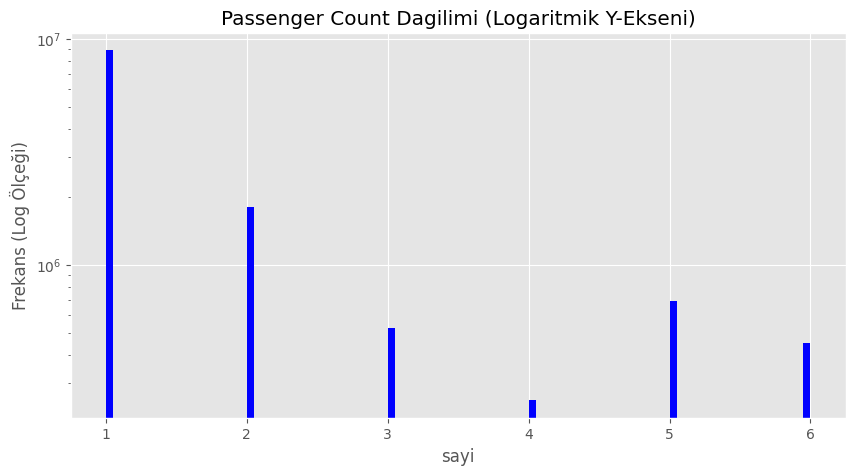

In [167]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['passenger_count'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Passenger Count Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('sayi')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin discrete dağılımını göstermektedir.

Passanger count discrete dağılıma sahip olduğundan, çalışması kolay oldu.

### 2.8 Trip Distance

In [168]:
indexes = df[df["trip_distance"] <= 0].index
df.drop(index=indexes, inplace=True)

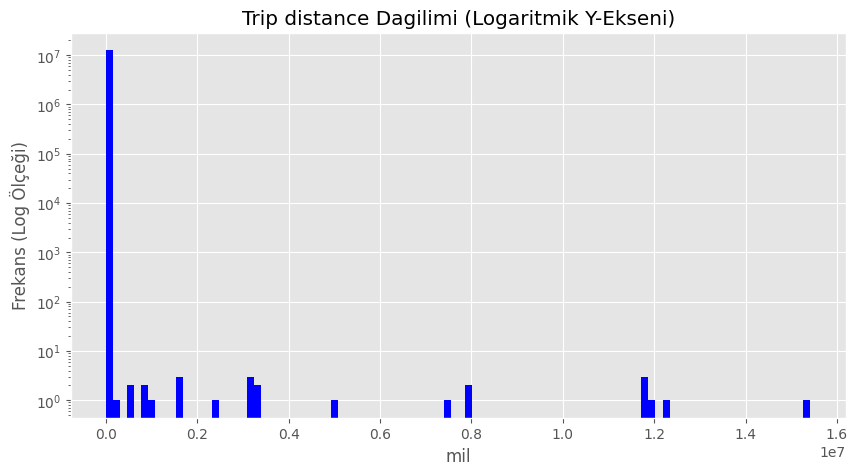

In [169]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_distance'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip distance Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('mil')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [170]:
df[df["trip_distance"] > (2 * 1e6)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
557966,2015-01-02 15:09:24,2015-01-02 15:13:08,1,12000000.0,1,237,236,2,4.5,0.0,0.5,0.00,0.0,0.0,5.30,3.733333
1010288,2015-01-03 18:26:48,2015-01-03 18:35:48,1,2331800.0,1,158,100,2,8.0,0.0,0.5,0.00,0.0,0.0,8.80,9.000000
1035770,2015-01-03 19:23:26,2015-01-03 19:42:38,1,3180000.0,1,68,142,1,14.5,0.0,0.5,1.00,0.0,0.0,16.30,19.200000
1392618,2015-01-04 19:14:56,2015-01-04 19:27:12,2,3180000.0,1,230,142,2,9.0,0.0,0.5,0.00,0.0,0.0,9.80,12.266667
3476422,2015-01-09 21:17:08,2015-01-09 21:39:42,1,8000016.5,1,138,33,1,28.0,0.5,0.5,5.86,0.0,0.3,35.16,22.566667
3480594,2015-01-09 22:02:58,2015-01-09 22:11:24,2,11800000.4,1,48,151,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80,8.433333
3480596,2015-01-09 22:54:09,2015-01-09 23:33:35,1,8000010.0,1,48,255,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30,39.433333
4390546,2015-01-11 19:01:17,2015-01-11 19:14:47,2,12331800.0,1,170,114,2,2.5,0.0,0.5,0.00,0.0,0.3,3.30,13.500000
4428834,2015-01-11 21:55:11,2015-01-11 22:24:16,1,15420004.5,1,113,14,2,34.5,0.5,0.5,0.00,0.0,0.3,35.80,29.083333
8725416,2015-01-21 21:03:19,2015-01-21 21:13:46,1,3318000.0,1,144,255,1,13.5,0.5,0.5,4.35,0.0,0.3,19.15,10.450000


In [171]:
indexes = df[df["trip_distance"] > (2 * 1e6)].index
df.drop(index=indexes, inplace=True)

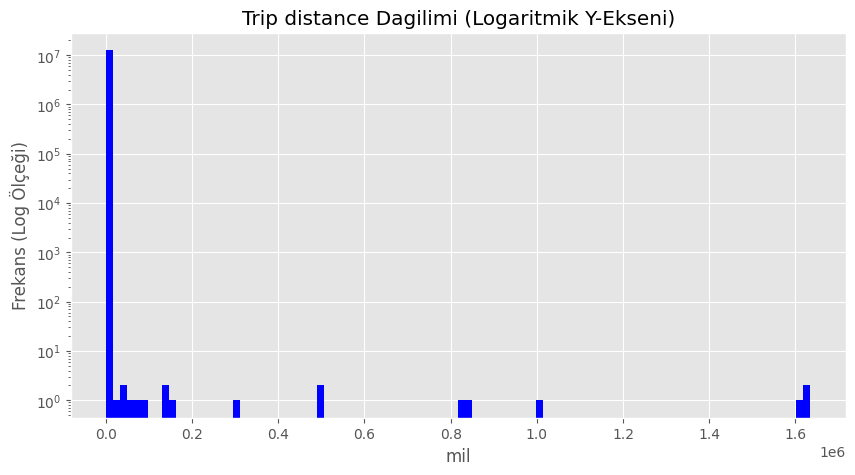

In [172]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_distance'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip distance Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('mil')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [173]:
df[df["trip_distance"] > (2 * 1e5)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
1164415,2015-01-04 01:55:38,2015-01-04 02:06:16,1,505331.8,1,246,141,1,12.0,0.5,0.5,1.5,0.0,0.0,14.8,10.633333
1316960,2015-01-04 15:41:34,2015-01-04 15:42:23,1,1635050.1,1,226,226,2,2.5,0.0,0.5,0.0,0.0,0.0,3.3,0.816667
1431245,2015-01-04 21:20:36,2015-01-04 21:38:58,1,834205.0,1,170,179,2,18.5,0.5,0.5,0.0,0.0,0.0,19.8,18.366667
3317271,2015-01-09 16:19:34,2015-01-09 16:20:03,1,1633973.4,1,112,112,4,2.5,1.0,0.5,0.0,0.0,0.3,4.3,0.483333
3504935,2015-01-09 22:52:15,2015-01-09 22:58:00,1,833180.0,1,75,236,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8,5.750000
3831577,2015-01-10 16:16:56,2015-01-10 16:18:05,1,1609837.1,4,50,50,3,3.5,0.0,0.5,0.0,0.0,0.3,4.3,1.150000
4411497,2015-01-11 20:45:16,2015-01-11 20:56:55,1,300000.0,1,48,141,1,9.5,0.5,0.5,1.5,0.0,0.3,12.3,11.650000
8642233,2015-01-21 18:09:38,2015-01-21 18:21:18,1,500501.3,1,143,162,2,9.0,1.0,0.5,0.0,0.0,0.3,10.8,11.666667
9192635,2015-01-22 22:39:29,2015-01-22 22:51:44,1,1000000.0,1,144,229,2,12.0,0.5,0.5,0.0,0.0,0.3,13.3,12.250000


In [174]:
indexes = df[df["trip_distance"] > (2 * 1e5)].index
df.drop(index=indexes, inplace=True)

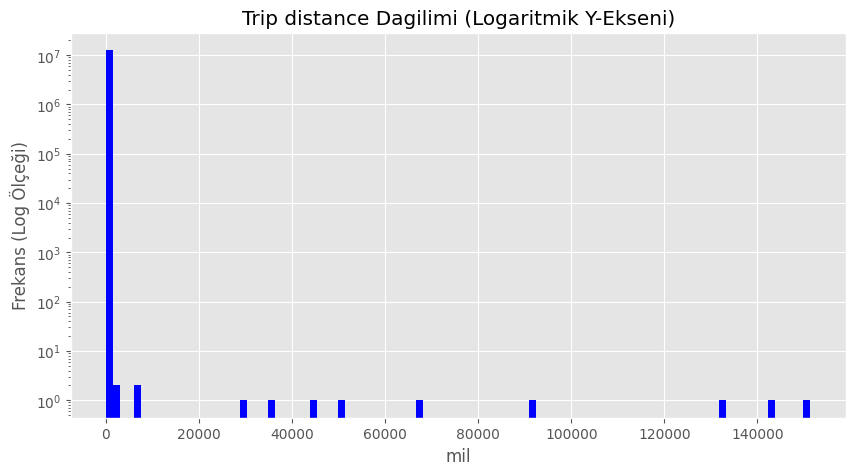

In [175]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_distance'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip distance Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('mil')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [176]:
df[df["trip_distance"] > 20000]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
1124279,2015-01-03 23:28:24,2015-01-03 23:49:28,1,133180.0,1,161,95,1,29.5,0.5,0.5,10.0,0.0,0.0,40.8,21.066667
1262251,2015-01-04 12:09:56,2015-01-04 12:29:17,1,66746.8,1,90,193,1,17.5,0.0,0.5,1.5,0.0,0.0,19.8,19.350000
1567076,2015-01-05 10:09:36,2015-01-05 10:09:50,1,142856.4,1,50,50,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3,0.233333
3582801,2015-01-10 01:07:05,2015-01-10 01:18:59,1,30083.2,1,79,262,1,14.0,0.5,0.5,2.0,0.0,0.3,17.3,11.900000
8698390,2015-01-21 20:10:41,2015-01-21 20:20:18,1,45000.0,1,100,107,1,9.0,0.5,0.5,2.0,0.0,0.3,12.3,9.616667
9345823,2015-01-23 09:37:16,2015-01-23 10:00:05,1,92000.9,1,230,151,2,2.5,0.0,0.5,0.0,0.0,0.3,3.3,22.816667
12317526,2015-01-31 06:43:00,2015-01-31 06:59:20,1,151401.3,1,68,236,1,13.5,0.0,0.5,1.0,0.0,0.3,15.3,16.333333
12563938,2015-01-31 18:45:59,2015-01-31 19:35:36,1,35005.0,1,50,181,2,28.0,0.0,0.5,0.0,0.0,0.3,28.8,49.616667
12681976,2015-01-31 22:25:52,2015-01-31 22:35:35,2,50333.1,1,237,48,2,8.0,0.5,0.5,0.0,0.0,0.3,9.3,9.716667


In [177]:
df["trip_distance"].quantile(0.999)

np.float64(22.88)

In [178]:
indexes = df[df["trip_distance"] > 20000].index
df.drop(index=indexes, inplace=True)

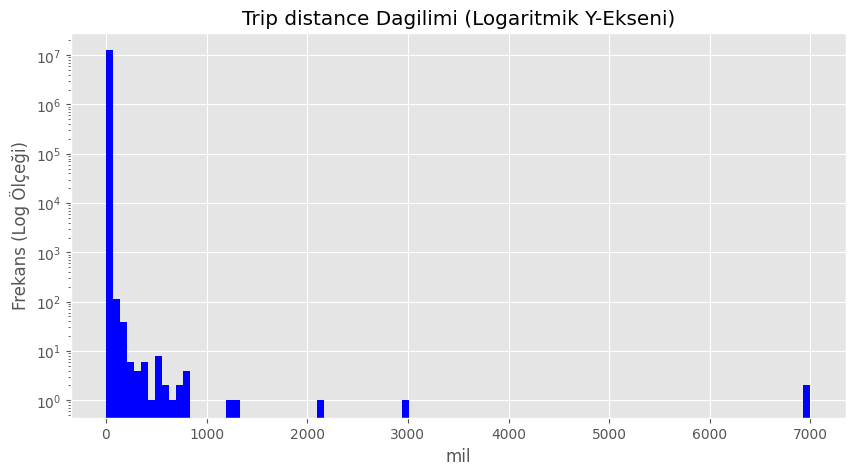

In [179]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_distance'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip distance Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('mil')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [180]:
df[df["trip_distance"] > 1000]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
986484,2015-01-03 17:00:22,2015-01-03 17:17:46,1,2100.5,1,246,144,1,14.5,0.0,0.5,3.0,0.00,0.0,18.30,17.400000
1190798,2015-01-04 03:13:11,2015-01-04 03:22:01,1,7000.0,1,249,79,2,9.0,0.5,0.5,0.0,0.00,0.0,10.30,8.833333
3504933,2015-01-09 22:09:21,2015-01-09 22:33:57,1,3008.3,1,138,50,1,27.5,0.5,0.5,1.5,5.33,0.3,35.63,24.600000
4019522,2015-01-10 22:39:56,2015-01-10 22:59:36,1,1200.5,1,114,229,1,14.0,0.5,0.5,2.0,0.00,0.3,17.30,19.666667
9579836,2015-01-23 20:50:18,2015-01-23 21:06:12,2,7000.0,1,68,166,1,16.5,0.5,0.5,2.2,0.00,0.3,20.00,15.900000
10154078,2015-01-25 00:58:33,2015-01-25 01:20:17,3,1274.6,1,50,79,2,15.5,0.5,0.5,0.0,0.00,0.3,16.80,21.733333


In [181]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["trip_distance"].quantile(0.25)
Q3 = df["trip_distance"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 1.0, Q3: 3.01, IQR: 2.01
Lower Bound: -2.0149999999999997, Upper Bound: 6.0249999999999995


IQR değeri çok hafif kalıyor!

In [182]:
df["trip_distance"].median()

np.float64(1.7)

In [183]:
df["trip_distance"].quantile(0.999)

np.float64(22.87)

In [184]:
# Median Absolute Deviation for trip_distance
df["trip_distance_normalize"] = np.log1p(df["trip_distance"])
general_median = df["trip_distance_normalize"].median()
sapmalar = (df["trip_distance_normalize"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_trip_distance_normalize"] = (0.6745 * (df["trip_distance_normalize"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,trip_distance_normalize,advanced_zscore_for_trip_distance_normalize
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000,0.693147,0.593736
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333,0.641854,0.695217
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333,1.504077,1.010634
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000,1.131402,0.273321
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000,0.693147,0.593736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000,0.955511,0.074667
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667,0.470004,1.035211
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333,1.386294,0.777608
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000,2.066863,2.124066


In [185]:
df[df["advanced_zscore_for_trip_distance_normalize"] > 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,trip_distance_normalize,advanced_zscore_for_trip_distance_normalize
227,2015-01-01 00:54:46,2015-01-01 01:36:15,2,21.00,2,132,209,2,52.0,0.0,0.5,0.00,0.00,0.0,52.80,41.483333,3.091042,4.150336
425,2015-01-01 00:28:08,2015-01-01 00:53:00,1,18.60,2,132,263,2,52.0,0.0,0.5,0.00,5.33,0.0,58.13,24.866667,2.975530,3.921801
568,2015-01-01 00:43:02,2015-01-01 01:12:18,1,19.09,2,132,263,1,52.0,0.0,0.5,11.47,5.33,0.3,69.60,29.266667,3.000222,3.970654
576,2015-01-01 00:13:50,2015-01-01 00:37:29,2,17.40,2,132,107,1,52.0,0.0,0.5,11.60,5.33,0.0,69.73,23.650000,2.912351,3.796806
629,2015-01-01 00:46:59,2015-01-01 01:16:56,3,21.20,1,132,40,2,56.0,0.5,0.5,0.00,0.00,0.0,57.30,29.950000,3.100092,4.168240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12740070,2015-01-31 23:34:37,2015-02-01 00:05:48,2,15.10,1,132,256,1,43.5,0.5,0.5,8.96,0.00,0.3,53.76,31.183333,2.778819,3.532624
12740250,2015-01-31 23:16:31,2015-01-31 23:58:15,1,16.40,1,186,174,1,49.5,0.5,0.5,10.15,0.00,0.3,60.95,41.733333,2.856470,3.686251
12740444,2015-01-31 23:19:31,2015-01-31 23:43:26,1,19.30,2,132,262,1,52.0,0.0,0.5,11.60,5.33,0.3,69.73,23.916667,3.010621,3.991227
12740445,2015-01-31 23:55:43,2015-02-01 00:35:57,2,15.50,1,262,165,1,46.5,0.5,0.5,5.00,0.00,0.3,52.80,40.233333,2.803360,3.581176


In [186]:
df[df["trip_distance"] > 25]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,trip_distance_normalize,advanced_zscore_for_trip_distance_normalize
714,2015-01-01 00:17:51,2015-01-01 00:58:34,1,25.80,1,43,29,1,68.7,0.5,0.5,14.00,0.00,0.0,84.00,40.716667,3.288402,4.540798
4777,2015-01-01 00:34:31,2015-01-01 01:33:33,5,26.93,1,132,93,2,75.0,0.5,0.5,0.00,0.00,0.3,76.30,59.033333,3.329701,4.622506
15515,2015-01-01 00:50:08,2015-01-01 01:25:54,2,27.96,5,68,265,1,137.0,0.0,0.5,29.60,11.00,0.3,178.40,35.766667,3.365916,4.694153
18090,2015-01-01 00:55:07,2015-01-01 02:08:02,4,30.00,1,142,84,1,87.5,0.5,0.5,24.85,10.66,0.0,124.31,72.916667,3.433987,4.828829
24609,2015-01-01 00:36:12,2015-01-01 01:53:14,1,29.20,1,186,113,1,85.5,0.5,0.5,10.00,5.33,0.0,102.13,77.033333,3.407842,4.777102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12737453,2015-01-31 23:27:11,2015-02-01 00:06:37,2,25.51,1,132,18,1,66.5,0.5,0.5,0.00,5.33,0.3,73.13,39.433333,3.277522,4.519273
12738348,2015-01-31 23:09:52,2015-02-01 00:11:44,3,27.40,1,186,27,2,77.5,0.5,0.5,0.00,2.00,0.3,80.80,61.866667,3.346389,4.655522
12738807,2015-01-31 23:40:00,2015-02-01 00:34:56,1,28.80,1,140,265,1,80.0,0.5,0.5,16.25,0.00,0.3,97.55,54.933333,3.394508,4.750722
12739292,2015-01-31 23:55:19,2015-02-01 00:51:27,1,29.10,5,100,265,1,125.0,0.0,0.0,31.32,0.00,0.3,156.62,56.133333,3.404525,4.770540


Manhattan uçyan uca 13.5 mil. Birisi git gel yapsa tüm adayı 27 mil. 30' a yuvarlayayım

In [187]:
indexes = df[df["trip_distance"] > 30].index
df.drop(index=indexes, inplace=True)

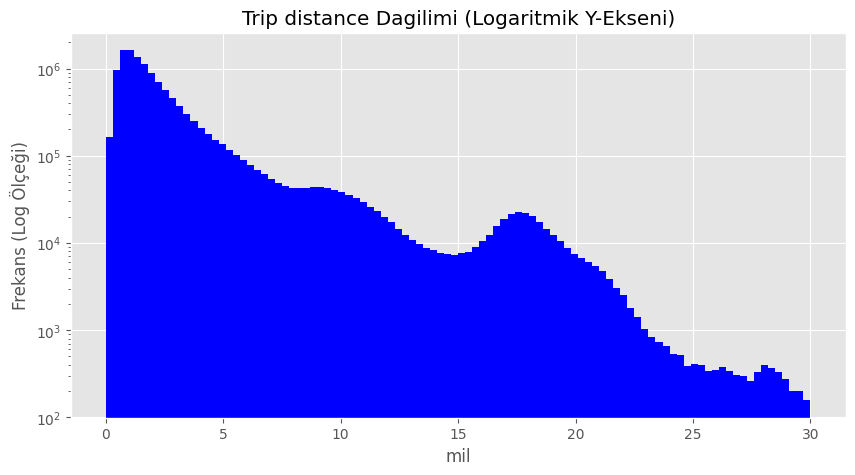

In [188]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['trip_distance'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Trip distance Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('mil')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [189]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount', 'duration',
       'trip_distance_normalize',
       'advanced_zscore_for_trip_distance_normalize'],
      dtype='object')

In [190]:
df.drop(columns=["trip_distance_normalize", 
                 "advanced_zscore_for_trip_distance_normalize"], inplace=True)

### 2.9 RateCodeID

In [191]:
df[df["RatecodeID"] == 99]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
39003,2015-01-01 01:16:26,2015-01-01 02:30:00,1,7.5,99,239,237,1,29.5,0.5,0.5,0.00,0.0,0.0,30.50,73.566667
55934,2015-01-01 01:57:00,2015-01-01 02:00:31,1,0.6,99,236,262,1,4.5,0.5,0.5,1.00,0.0,0.0,6.50,3.516667
166920,2015-01-01 10:01:36,2015-01-01 10:24:49,4,14.0,99,88,138,1,38.0,0.0,0.5,7.70,0.0,0.0,46.20,23.216667
355319,2015-01-01 21:01:08,2015-01-01 21:19:49,1,4.2,99,79,142,1,16.5,0.5,0.5,2.50,0.0,0.0,20.00,18.683333
443072,2015-01-02 09:41:08,2015-01-02 09:49:56,1,1.6,99,239,230,1,8.5,0.0,0.5,1.80,0.0,0.0,10.80,8.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12218474,2015-01-30 23:49:22,2015-01-30 23:53:19,1,0.7,99,79,4,1,5.0,0.5,0.5,0.00,0.0,0.3,6.30,3.950000
12275133,2015-01-31 02:45:58,2015-01-31 02:59:07,1,3.6,99,144,50,2,13.5,0.5,0.5,0.00,0.0,0.3,14.80,13.150000
12390355,2015-01-31 11:11:27,2015-01-31 11:40:32,1,9.0,99,236,256,1,29.0,0.0,0.5,3.00,0.0,0.3,32.80,29.083333
12546750,2015-01-31 17:14:31,2015-01-31 17:27:37,1,2.5,99,144,186,1,11.5,0.0,0.5,2.00,0.0,0.3,14.30,13.100000


In [192]:
indexes = df[df["RatecodeID"] == 99].index
df.drop(index=indexes, inplace=True)

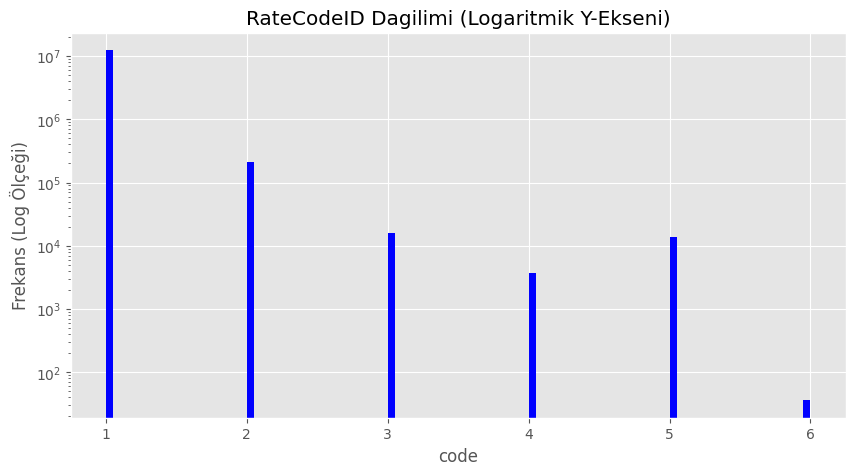

In [193]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['RatecodeID'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('RateCodeID Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('code')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

### 2.99 speed

In [194]:
df["speed"] = (df["trip_distance"] / df["duration"]) * 60 * 1.61
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,speed
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000,18.400000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333,14.652809
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333,22.870349
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000,25.678481
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000,15.966942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000,16.619355
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667,8.502689
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333,13.489527
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000,14.272805


In [195]:
df["speed"].max()

np.float64(13813.800000000001)

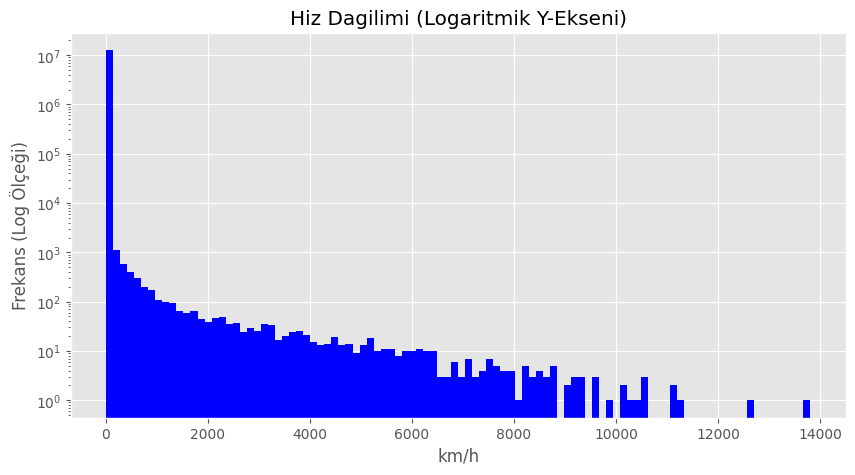

In [196]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['speed'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Hiz Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('km/h')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [197]:
df[df["speed"] > 12000]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,speed
3102850,2015-01-09 00:55:57,2015-01-09 00:56:09,1,26.2,1,264,265,3,2.5,0.5,0.5,0.00,0.00,0.3,3.80,0.2,12654.6
10714530,2015-01-26 13:25:10,2015-01-26 13:25:22,1,28.6,2,132,264,1,52.0,0.0,0.5,11.63,5.33,0.3,69.76,0.2,13813.8


In [198]:
df[df["speed"] <= 0]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,speed


In [199]:
df[df["speed"] > 110]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,speed
338,2015-01-01 00:51:32,2015-01-01 00:52:11,1,0.80,1,48,48,2,2.5,0.5,0.5,0.00,0.0,0.0,3.80,0.650000,118.892308
1145,2015-01-01 00:38:11,2015-01-01 00:38:29,1,2.60,1,141,141,2,2.5,0.5,0.5,0.00,0.0,0.0,3.80,0.300000,837.200000
1758,2015-01-01 00:40:25,2015-01-01 00:40:42,1,10.10,5,41,41,1,77.0,0.0,0.0,3.00,0.0,0.0,80.30,0.283333,3443.505882
1981,2015-01-01 00:05:44,2015-01-01 00:05:56,1,3.00,1,48,48,2,2.5,0.5,0.5,0.00,0.0,0.0,3.80,0.200000,1449.000000
4041,2015-01-01 00:06:44,2015-01-01 00:07:06,2,7.80,1,238,238,2,2.5,0.5,0.5,0.00,0.0,0.0,3.80,0.366667,2054.945455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12736728,2015-01-31 23:20:54,2015-01-31 23:21:25,1,3.70,1,255,255,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.516667,691.780645
12737788,2015-01-31 23:18:40,2015-01-31 23:20:22,1,5.74,1,87,87,1,17.5,0.5,0.5,5.64,0.0,0.3,24.44,1.700000,326.167059
12739478,2015-01-31 23:23:38,2015-01-31 23:23:59,1,2.20,1,264,264,3,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.350000,607.200000
12740267,2015-01-31 23:47:24,2015-01-31 23:48:34,1,3.50,1,158,158,2,3.0,0.5,0.5,0.00,0.0,0.3,4.30,1.166667,289.800000


In [200]:
percentage = 100 * (len(df[df["speed"] > 110]) / len(df))
print(f"110 km/h den hizli gidenler", percentage)

110 km/h den hizli gidenler 0.035199651663676716


Kurallara göre bir taksi 110 km/h hız sınırını aşamaz ve bu satırları keseceğim

In [201]:
indexes = df[df["speed"] > 110].index
df.drop(index=indexes, inplace=True)

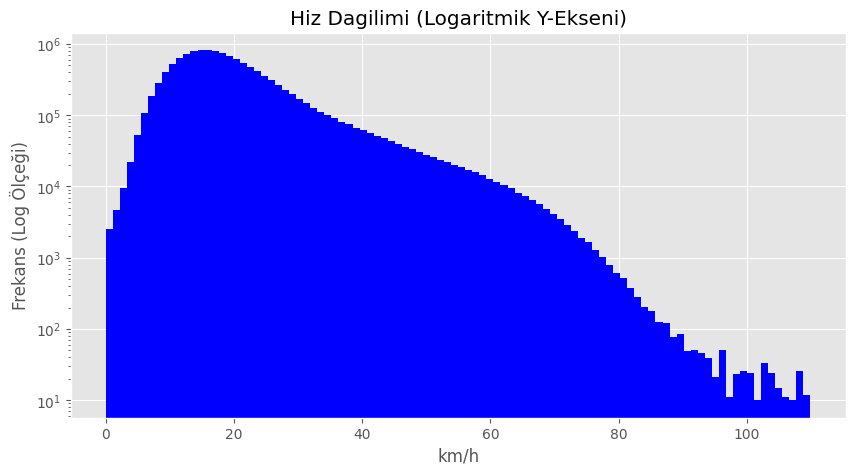

In [202]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['speed'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Hiz Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('km/h')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin dağılımını göstermektedir.

In [203]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount', 'duration',
       'speed'],
      dtype='object')

In [204]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,speed
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,5.250000,18.400000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,5.933333,14.652809
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,14.783333,22.870349
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,7.900000,25.678481
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,6.050000,15.966942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,9.300000,16.619355
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,6.816667,8.502689
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,21.483333,13.489527
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,46.700000,14.272805


In [205]:
percentage = 100 * (12617841 / 12741035)
print(f"Veri temizliği sonucu kalan satirlarin yuzdesi: {percentage}")

Veri temizliği sonucu kalan satirlarin yuzdesi: 99.0330926804612


In [206]:
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,speed
count,12617841,12617841,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07,1.261784e+07
mean,2015-01-16 14:44:33.076529,2015-01-16 14:56:52.717429,1.684411e+00,2.788182e+00,1.024226e+00,1.631433e+02,1.608334e+02,1.383056e+00,1.182563e+01,3.090026e-01,4.989533e-01,1.525386e+00,2.372224e-01,2.832245e-01,1.469570e+01,1.232735e+01,2.010725e+01
min,2015-01-01 00:00:00,2015-01-01 00:01:25,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+00,2.000000e-01,1.054202e-02
25%,2015-01-09 09:28:26,2015-01-09 09:44:59,1.000000e+00,1.000000e+00,1.000000e+00,1.130000e+02,1.070000e+02,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,6.166667e+00,1.352264e+01
50%,2015-01-16 11:44:09,2015-01-16 11:57:40,1.000000e+00,1.700000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01,1.000000e+01,1.783385e+01
75%,2015-01-23 19:16:02,2015-01-23 19:29:02,2.000000e+00,3.010000e+00,1.000000e+00,2.330000e+02,2.330000e+02,2.000000e+00,1.350000e+01,5.000000e-01,5.000000e-01,2.060000e+00,0.000000e+00,3.000000e-01,1.630000e+01,1.581667e+01,2.378078e+01
max,2015-01-31 23:59:59,2015-02-01 01:00:47,6.000000e+00,3.000000e+01,6.000000e+00,2.650000e+02,2.650000e+02,5.000000e+00,3.500000e+02,2.000000e+00,5.000000e-01,9.365000e+01,2.500000e+01,3.000000e-01,4.059500e+02,1.000667e+02,1.099241e+02
std,NaN,NaN,1.339470e+00,3.320535e+00,1.994638e-01,6.718888e+01,7.068333e+01,4.941758e-01,9.460404e+00,3.613296e-01,2.285324e-02,2.092396e+00,1.189772e+00,6.892912e-02,1.157708e+01,9.034668e+00,1.009686e+01


In [207]:
df.to_parquet("yellow_tripdata_2015-01_temizlenmis.parquet", index=False)